In [188]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [189]:
def load_coerece(experiment):
    folder = f"results/coerence_{experiment}"
    t = np.load(os.path.join(folder, "t.npy"))

    if experiment in ['cos1', 'cos2','cos3',"cos5",'linear1', 'linear2', 'linear3', 'linear4', 'linear5', 'linear6',
                      'exp1', 'exp2', 'exp3', 'exp4', 'exp5', 'exp6']:
        list = np.load(os.path.join(folder, "w_list.npy"))
    elif experiment in ['gauss1', 'gauss2', 'gauss4','gauss5']:
        list = np.load(os.path.join(folder, "ep_list.npy")) 
    elif experiment in ['gauss3','gauss6']:
        list = np.load(os.path.join(folder, "T_list.npy"))
    elif experiment in ['cos4']:
        list = np.load(os.path.join(folder, 'phi_list.npy'))

    var_aberto = np.load(os.path.join(folder, "var_aberto.npy"), allow_pickle=True)
    const_aberto = np.load(os.path.join(folder, "const_aberto.npy"), allow_pickle=True)

    C_wt = np.vstack([np.asarray(row, dtype=np.complex128).ravel() for row in var_aberto])
    C_wt = np.real(C_wt)  # coherence should be real; keep real part safely

    const_aberto = np.asarray(const_aberto, dtype=np.complex128).ravel()
    const_aberto = np.real(const_aberto)

    # Difference: var_aberto(w,t) - const_aberto(t)
    D_wt = C_wt - const_aberto[None, :]
    return list, C_wt, D_wt, const_aberto, t


# --- MINIMAL ADD: centers -> edges (for non-uniform spacing) ---
def _edges_from_centers(x):
    x = np.asarray(x)
    dx = np.diff(x)
    edges = np.empty(x.size + 1, dtype=x.dtype)
    edges[1:-1] = x[:-1] + dx / 2
    edges[0] = x[0] - dx[0] / 2
    edges[-1] = x[-1] + dx[-1] / 2
    return edges


def plot_coherence_and_difference(
    t,
    list,
    C_wt,
    D_wt,
    cmap_var=None,
    cmap_diff=None,
    experiment="linear1"
):

    # --- MINIMAL ADD: edges for non-uniform t/list ---
    t_edges = _edges_from_centers(t)
    list_edges = _edges_from_centers(list)

    # ==========================
    # Plot 1: Coerência
    # ==========================
    plt.figure()
    plt.pcolormesh(
        t_edges, list_edges, C_wt,
        shading="auto",
        cmap=cmap_var
    )
    plt.xlabel("$t$",fontsize=20)

    if experiment in ['cos1', 'cos2', 'cos3', 'linear1', 'linear2', 'linear3', 'linear4', 'linear5', 'linear6',
                      'exp1', 'exp2', 'exp3', 'exp4', 'exp5', 'exp6']:
        plt.ylabel(r"$\omega$",fontsize=20)
    elif experiment in ['gauss1', 'gauss2', 'gauss4', 'gauss5']:
        plt.ylabel(r"$\zeta$",fontsize=20)
    elif experiment in ['gauss3','gauss6']:
        plt.ylabel(r"$T$",fontsize=20)
    elif experiment in ['cos4']:
        plt.ylabel(r'$\phi$', fontsize=20)

    plt.colorbar(label=r"$C(\rho^{(Q)})$")
    plt.tight_layout()
    plt.show()

    # ==========================
    # Plot 2: Diferença
    # ==========================
    plt.figure()
    plt.pcolormesh(
        t_edges, list_edges, D_wt,
        shading="auto",
        cmap=cmap_diff
    )
    plt.xlabel("t",fontsize=20)

    if experiment in ['linear1', 'linear2', 'linear3', 'linear4', 'linear5', 'linear6',
                      'exp1', 'exp2', 'exp3', 'exp4', 'exp5', 'exp6']:
        plt.ylabel(r"$\omega$", fontsize=20)
    elif experiment in ['gauss1', 'gauss2', 'gauss4', 'gauss5']:
        plt.ylabel(r"$\zeta$", fontsize=20)
    elif experiment in ['gauss3','gauss6']:
        plt.ylabel(r"$T$", fontsize=20)
    elif experiment in ['cos4']:
        plt.ylabel(r'$\phi$', fontsize=20)

    plt.colorbar(label=r"$\Delta C(\rho^{(Q)})$")
    plt.tight_layout()
    plt.show()


def plot_selected_coherences(
    t,
    const,
    C_wt,
    list,
    indices,
    scale_factor=1e-3,
    yscale="log"
):
    plt.figure()

    # curva constante
    plt.plot(t, const, label=r"$g_0$")

    # curvas selecionadas
    for i in indices:
        d_val = list[i]**2 / scale_factor
        label = rf"$g_t$ with $d={d_val:.5g}$"
        plt.plot(t, C_wt[i], label=label)

    plt.yscale(yscale)
    plt.xlabel("$t$", fontsize=20)
    plt.ylabel(r"$C(\rho^{Q})$")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 0. Parâmetros gerais



# 1. Exponenciais

Vamos considerar a modulação do tipo exponencial,

\begin{equation}
    g(t) = g_0 \exp(\omega t + \phi),
\end{equation}
mas modificando os tais parâmetros para compreender diferentes cenários físicos.

## 1.1 - Aumento exponencial começando de $g(0)\ll 1$
Aqui, vamos verificar tal comportamento fazendo $\phi=\ln(10^{-3})$ e $0<\omega<\frac{\ln(2)-\ln(10^{-3})}{T}$.


### 1.1.1 - $T$ grande o suficiente para cessar a dinâmica
Queremos verificar o corpotamento quando o sistema sofre grandes perdas. Para isso, utilizaremos $T=150$. Na figura abaixo, pode-se ver o comportamento do acoplamento.

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/4192384081.py:7: 

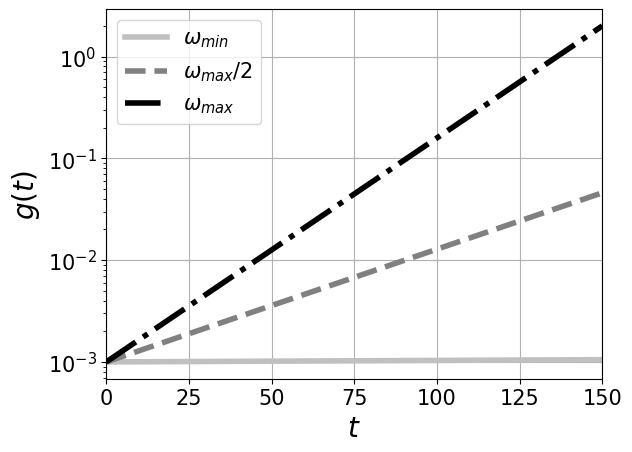

In [190]:
w_list, C_wt, D_wt, const, t = load_coerece('exp1')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']

for i, idx in enumerate(indices):
    g = np.exp(w_list[idx]*t + np.log(1e-3))
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 25, 50, 75, 100, 125, 150], fontsize=15)
plt.xlim(0, 150)
plt.grid(True)
plt.show()

In [191]:
t

array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
       4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
       8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
       1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
       1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
       2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
       2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
       2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
       3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
       3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
       4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
       4.40000000e-01, 4.50000000e-01, 4.60000000e-01, 4.70000000e-01,
       4.80000000e-01, 4.90000000e-01, 5.00000000e-01, 5.10000000e-01,
       5.20000000e-01, 5.30000000e-01, 5.40000000e-01, 5.50000000e-01,
      

As simulações para esses parâmetros são apresentadas abaixo, assim como a diferença entre os resultados para $g(t)$ e $g_0$, durante todo o intervalo de tempo.

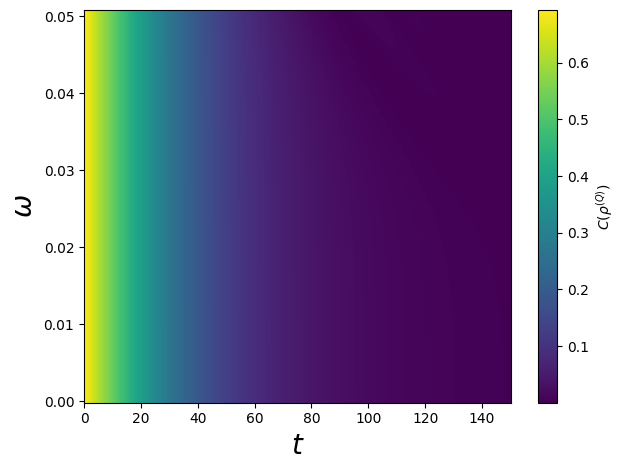

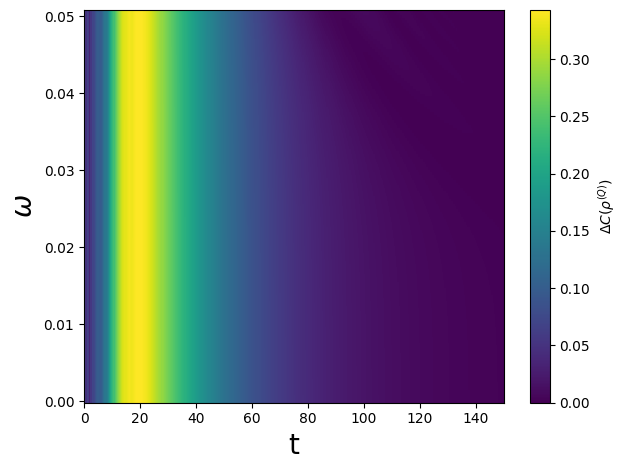

In [192]:
plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt
)

Para uma melhor comparação, olhamos para os três valores de acoplhamento vistos na primeira figura.

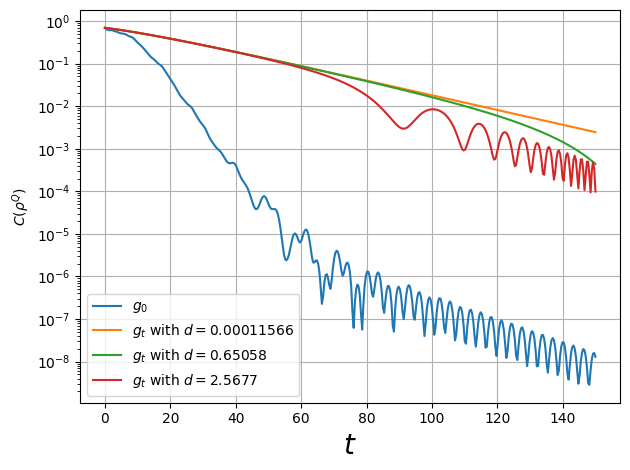

In [193]:
plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices
)

### 1.1.2 - $T$ menor, sem cessar a dinâmica
Queremos verificar o corpotamento quando o sistema não sofre grandes perdas. Para isso, utilizaremos $T=50$. Na figura abaixo, pode-se ver o comportamento do acoplamento.

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/3686399391.py:7: 

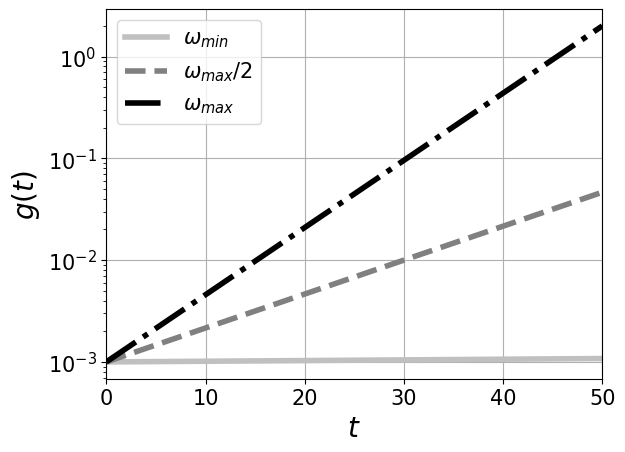

In [194]:
w_list, C_wt, D_wt, const, t = load_coerece('exp4')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']

for i, idx in enumerate(indices):
    g = np.exp(w_list[idx]*t + np.log(1e-3))
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 10, 20, 30, 40, 50], fontsize=15)
plt.xlim(0, 50)
plt.grid(True)
plt.show()

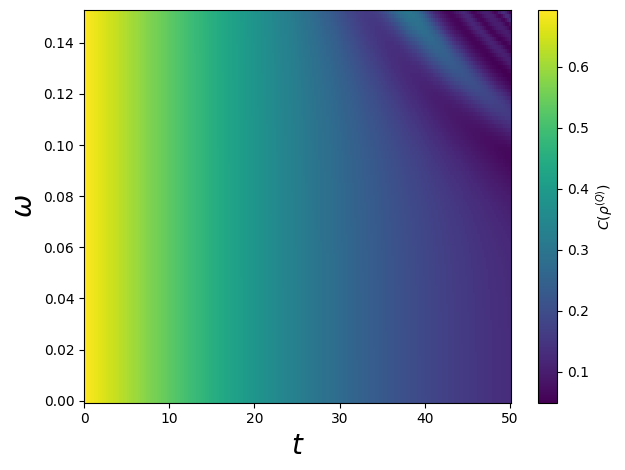

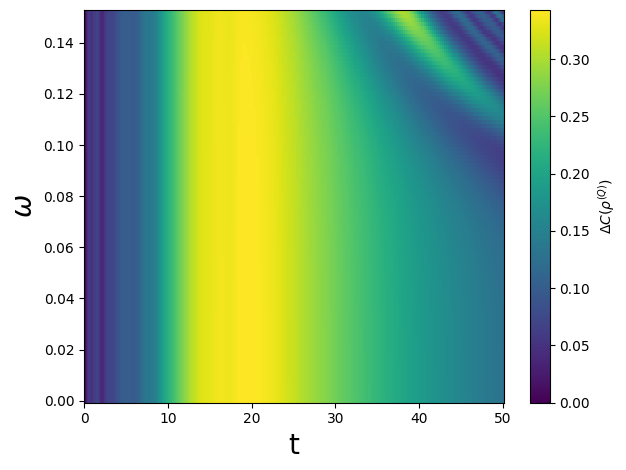

In [195]:
plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt
)

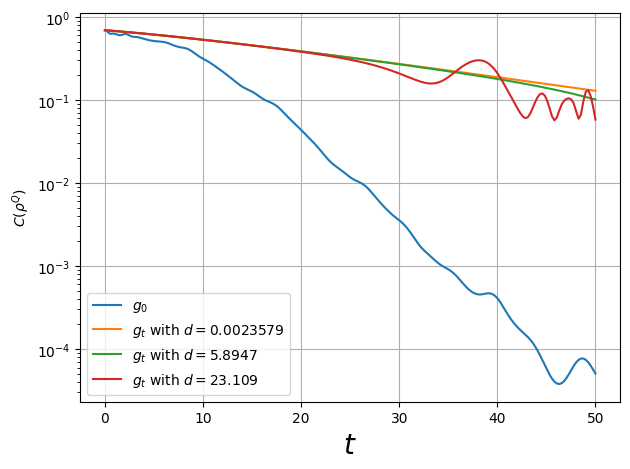

In [196]:
indices = [1, len(w_list)//2, -1]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices
)

## 1.2 - Diminuição exponencial começando de $g(0)= 1$
Aqui, vamos verificar tal comportamento fazendo $\phi=0$ e $\frac{\ln(10^{-3})}{T}<\omega<0$.

### 1.2.1 - $T$ grande o suficiente para cessar a dinâmica
$T=150$

In [ ]:
w_list, C_wt, D_wt, const, t = load_coerece('gauss1')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']

for i, idx in enumerate(indices):
    g = np.exp(w_list[idx]*t )
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 25, 50, 75, 100, 125, 150], fontsize=15)
plt.xlim(0, 150)
plt.grid(True)
plt.show()

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_25646/812678616.py:7: S

/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_25646/812678616.py:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_25646/812678616.py:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_25646/812678616.py:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']


NameError: name 'load_coerece' is not defined

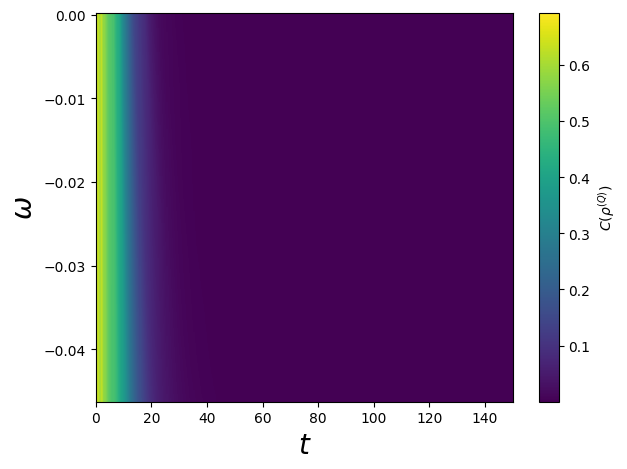

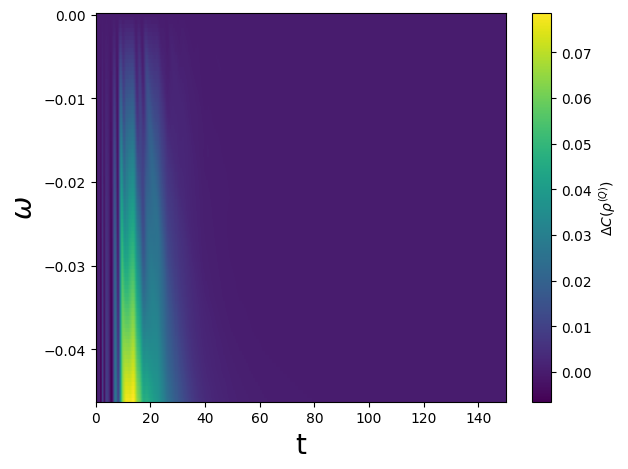

In [198]:
plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt
)

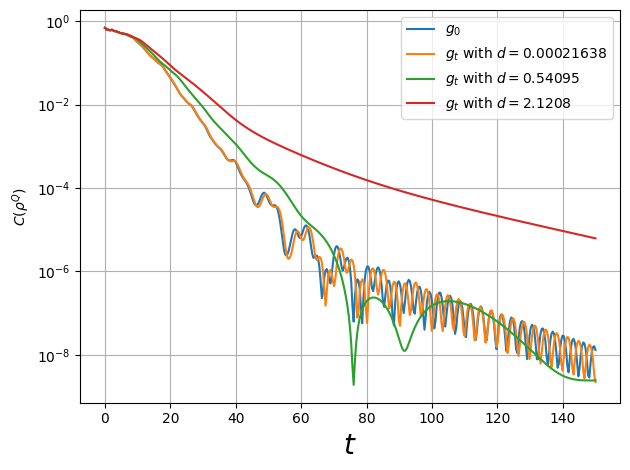

In [199]:
indices = [1, len(w_list)//2, -1]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices
)

### 1.2.2 - $T$ menor, sem cessar a dinâmica
Queremos verificar o corpotamento quando o sistema não sofre grandes perdas. Para isso, utilizaremos $T=50$. Na figura abaixo, pode-se ver o comportamento do acoplamento.

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/4105360765.py:7: 

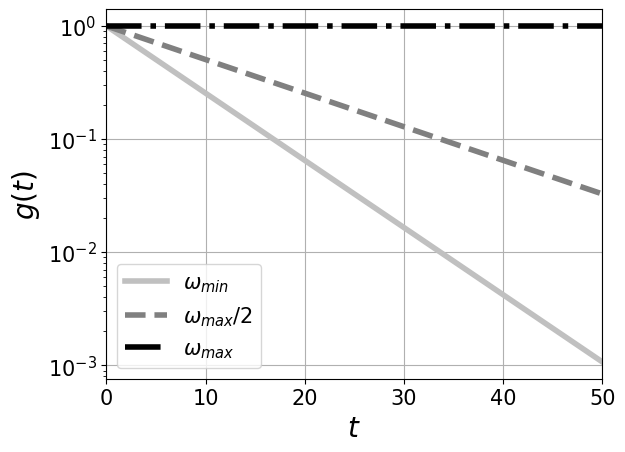

In [200]:
w_list, C_wt, D_wt, const, t = load_coerece('exp5')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']

for i, idx in enumerate(indices):
    g = np.exp(w_list[idx]*t)
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 10, 20, 30, 40, 50], fontsize=15) #[0, 25, 50, 75, 100, 125, 150]
plt.xlim(0, 50)
plt.grid(True)
plt.show()

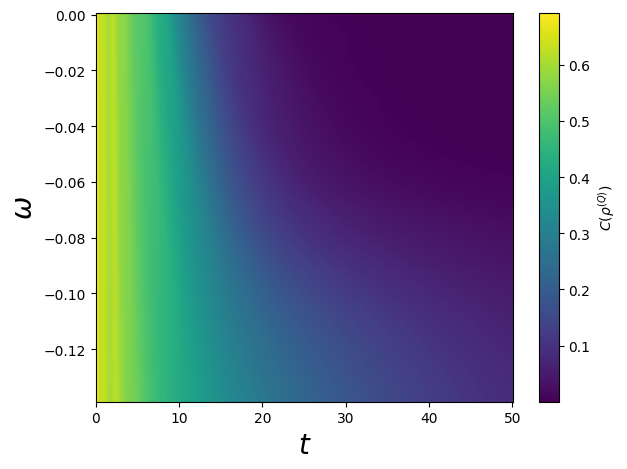

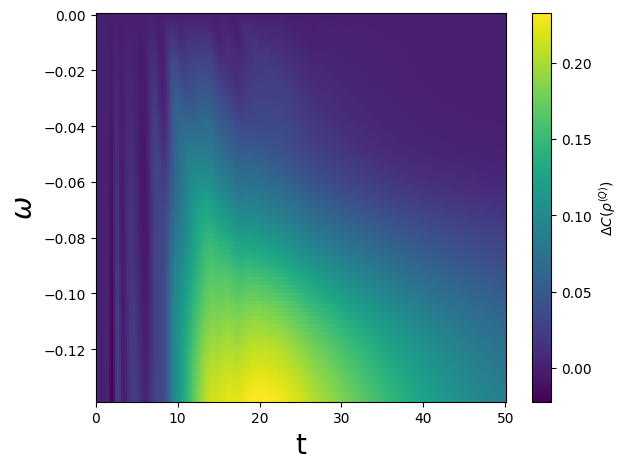

In [201]:
w_list, C_wt, D_wt, const, t = load_coerece('exp5')

plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt
)

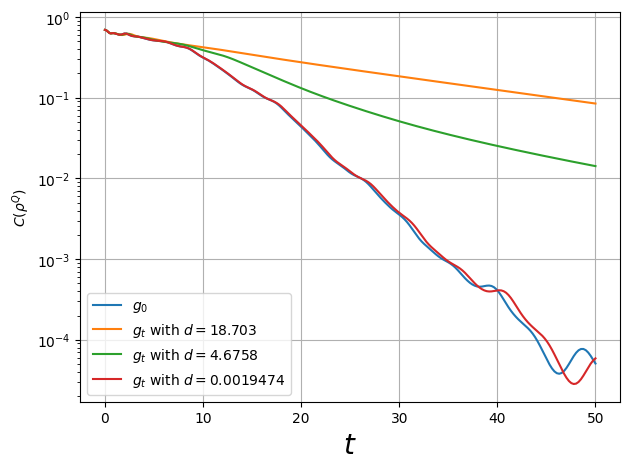

In [202]:
indices = [1, len(w_list)//2, -2]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices
)

## 1.3 Aumento exponencial suave de um acoplamento começando em $g(0)=1$
Aqui, vamos verifical tal comportamento fazendo $\phi=0$ e $0 < \omega \frac{\ln(2)}{T}$.

### 1.3.1 - $T$ grande o suficiente para cessar a dinâmica
$T=150$

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/1008602433.py:7: 

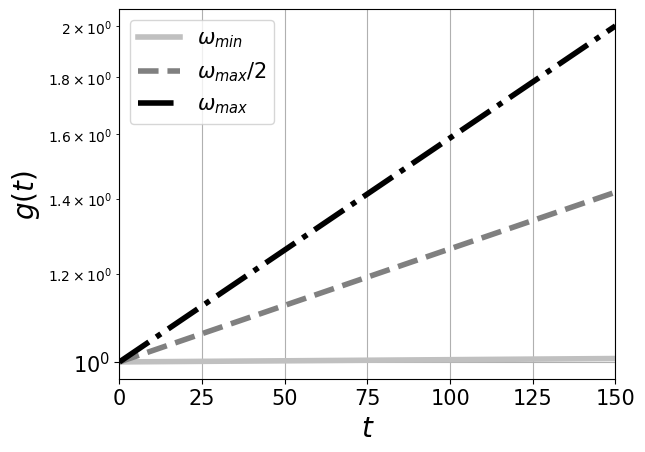

In [203]:
w_list, C_wt, D_wt, const, t = load_coerece('exp3')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']

for i, idx in enumerate(indices):
    g = np.exp(w_list[idx]*t )
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])

plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 25, 50, 75, 100, 125, 150], fontsize=15)
plt.xlim(0, 150)
plt.grid(True)
plt.show()

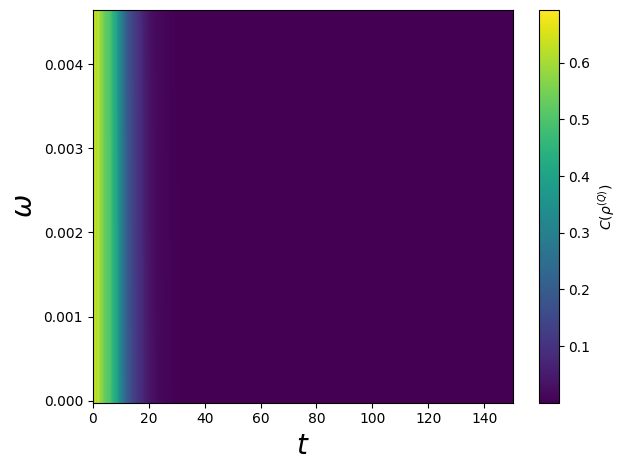

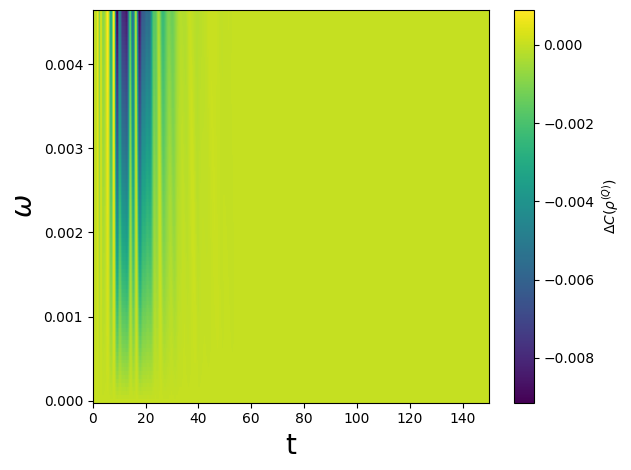

In [204]:
plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt
)

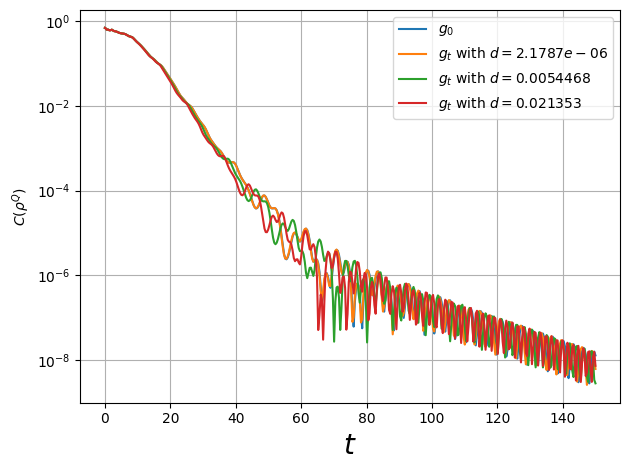

In [205]:
# Aqui aquele d não se aplica, pq sempre é muito menor omega do que os decaimentos
indices = [1, len(w_list)//2, -1]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices
)

### 1.2.2 - $T$ menor, sem cessar a dinâmica
Queremos verificar o corpotamento quando o sistema não sofre grandes perdas. Para isso, utilizaremos $T=50$. Na figura abaixo, pode-se ver o comportamento do acoplamento.

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/152014086.py:7: S

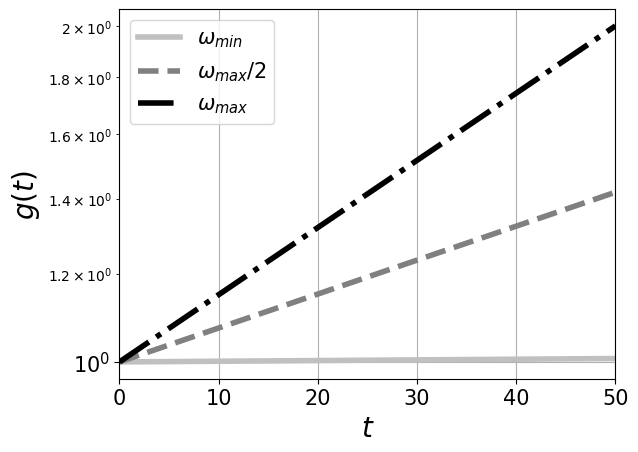

In [206]:
w_list, C_wt, D_wt, const, t = load_coerece('exp6')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']

for i, idx in enumerate(indices):
    g = np.exp(w_list[idx]*t )
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0,10, 20, 30, 40, 50], fontsize=15)
plt.xlim(0, 50)
plt.grid(True)
plt.show()

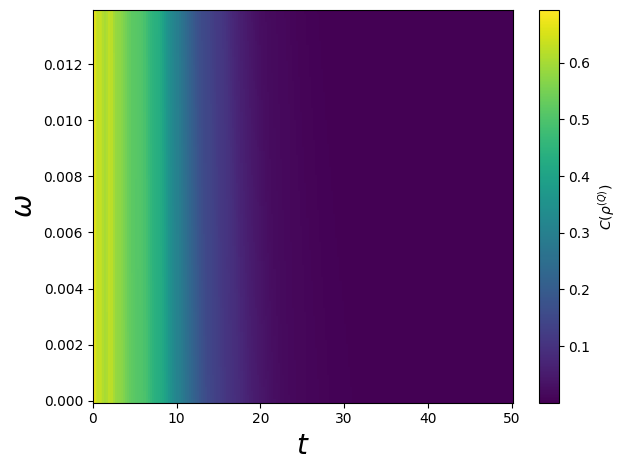

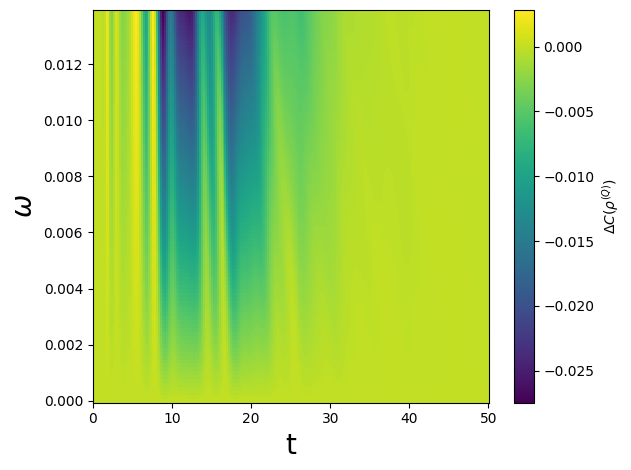

In [207]:
w_list, C_wt, D_wt, const, t = load_coerece('exp6')

plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt
)

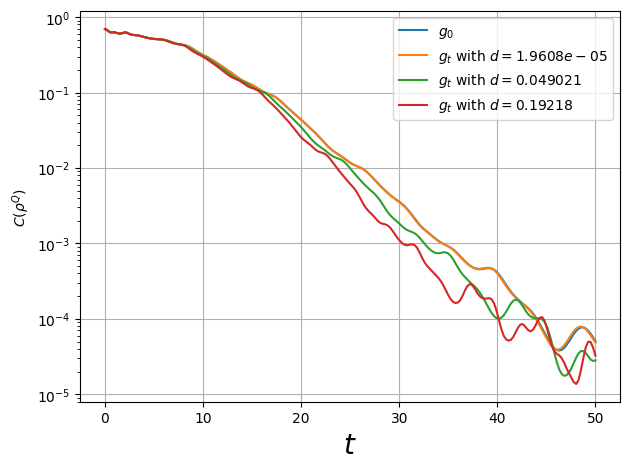

In [208]:
# Aqui aquele d não se aplica, pq sempre é muito menor omega do que os decaimentos
indices = [1, len(w_list)//2, -1]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices
)


# 2. Linear

Vamos considerar a modulação do tipo exponencial,

\begin{equation}
    g(t) = g_0 (\omega t + \phi),
\end{equation}
mas modificando os tais parâmetros para compreender diferentes cenários físicos.

## 2.1 Mudança Adiabática e Mudança Abrupta
Aqui, vamos verifical tal comportamento fazendo $\phi=0$ e $0 < \omega < 0.2$.

### 2.1.1 - $T$ grande
$T=150$

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/1513330285.py:7: 

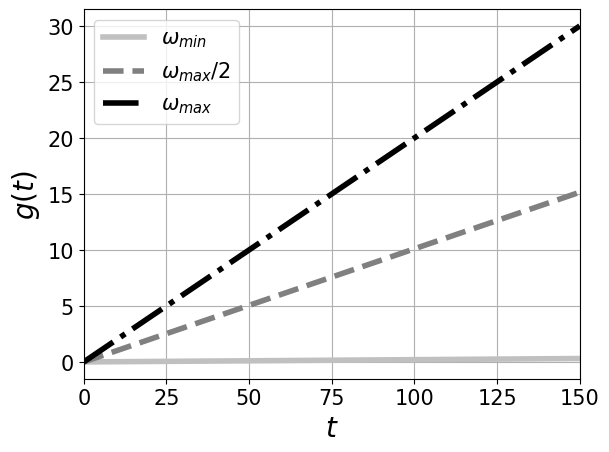

In [209]:
w_list, C_wt, D_wt, const, t = load_coerece('linear1')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']

for i, idx in enumerate(indices):
    g = w_list[idx]*t + 0
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])

plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 25, 50, 75, 100, 125, 150], fontsize=15)
plt.xlim(0, 150)
plt.grid(True)
plt.show()

In [210]:
'#FF69B4'

'#FF69B4'

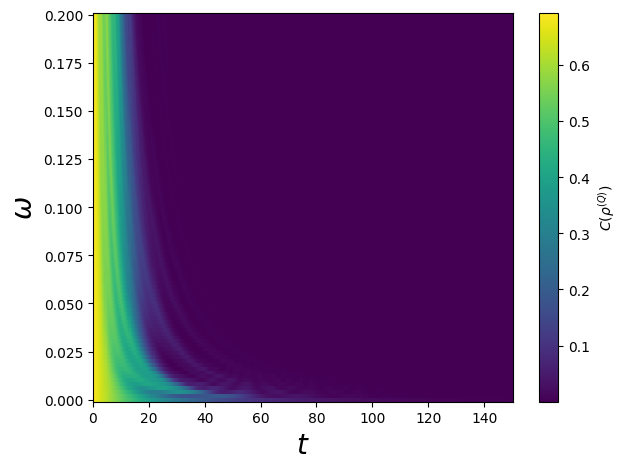

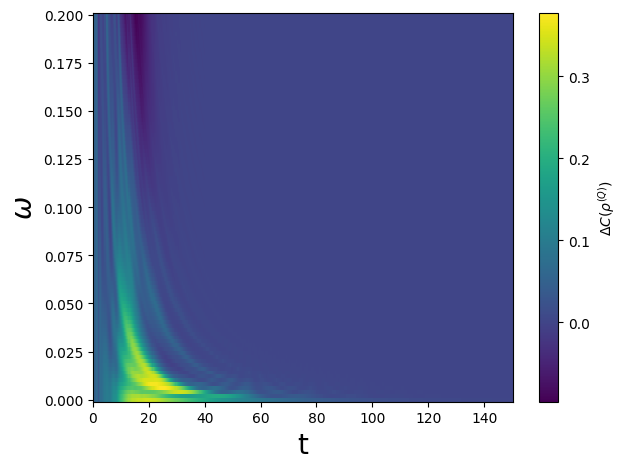

In [211]:
plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt
)

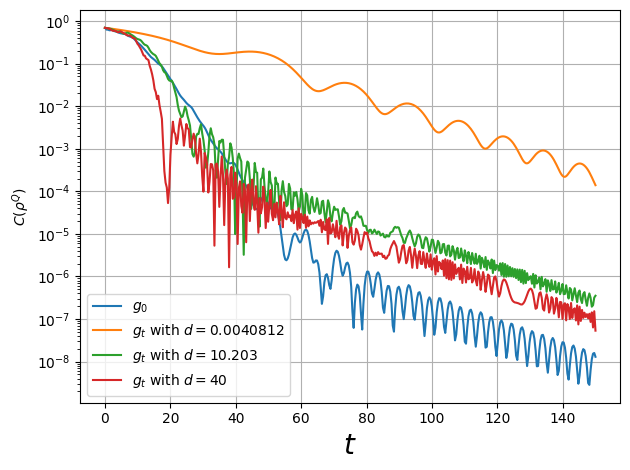

In [212]:
plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices
)


### 2.1.2 - $T$ pequeno
$T=50$

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/2988524581.py:7: 

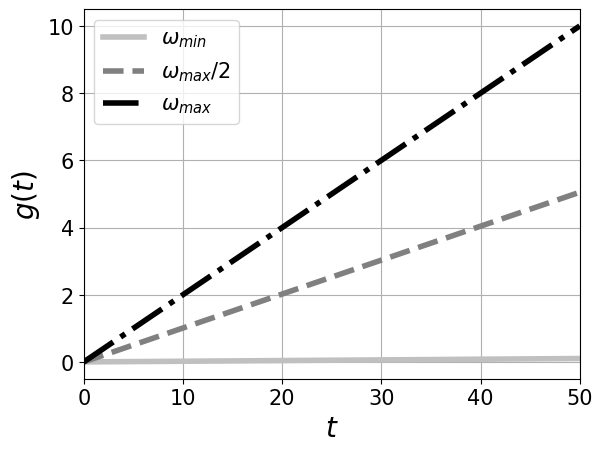

In [213]:
w_list, C_wt, D_wt, const, t = load_coerece('linear4')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']

for i, idx in enumerate(indices):
    g = w_list[idx]*t + 0
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])

plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 10, 20, 30, 40, 50], fontsize=15)
plt.xlim(0, 50)
plt.grid(True)
plt.show()

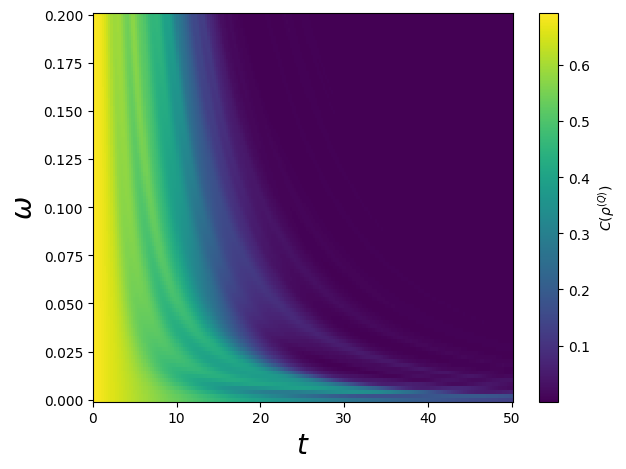

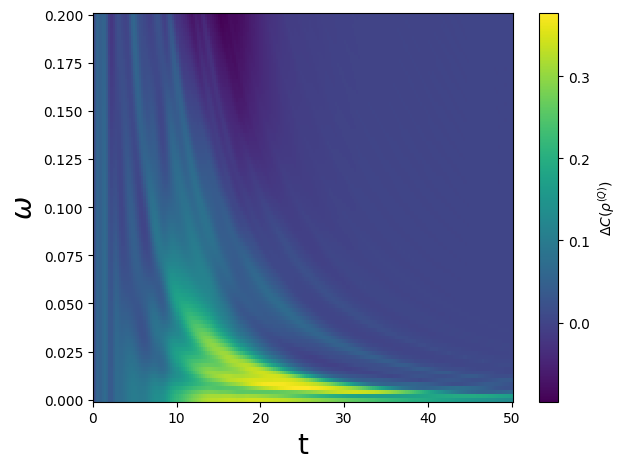

In [214]:
plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt
)

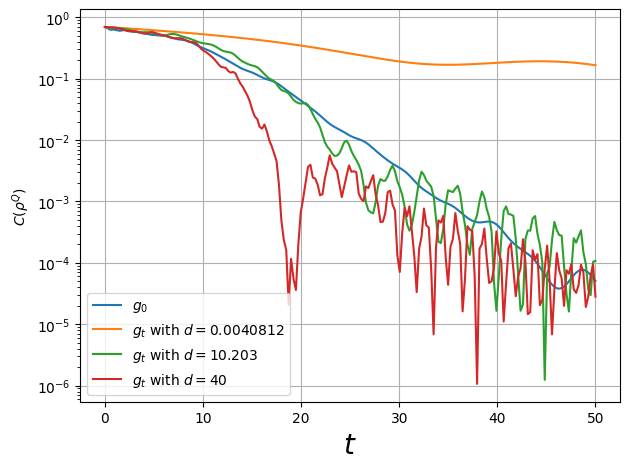

In [215]:
plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices
)


## 2.2 Decaimento até 0
Aqui, vamos verifical tal comportamento fazendo $\phi=1$ e $-\frac{1}{T} < \omega < 0$.

### 2.2.1 - $T$ grande
$T=150$

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/443798074.py:7: S

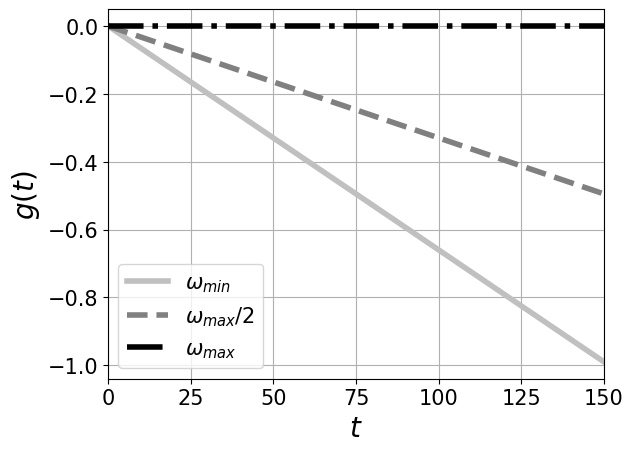

In [216]:
w_list, C_wt, D_wt, const, t = load_coerece('linear2')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']

for i, idx in enumerate(indices):
    g = w_list[idx]*t + 0
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])

plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 25, 50, 75, 100, 125, 150], fontsize=15)
plt.xlim(0, 150)
plt.grid(True)
plt.show()

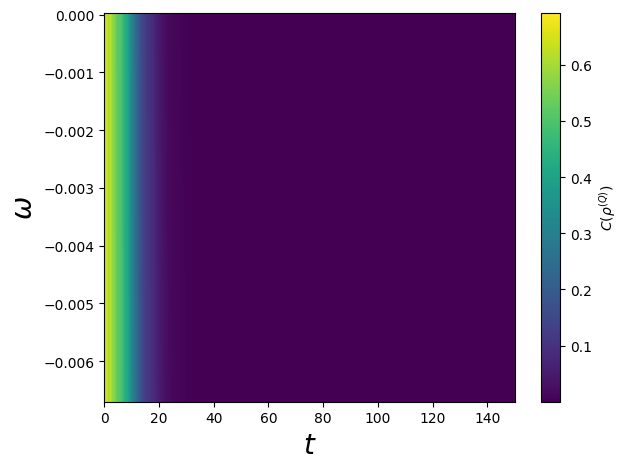

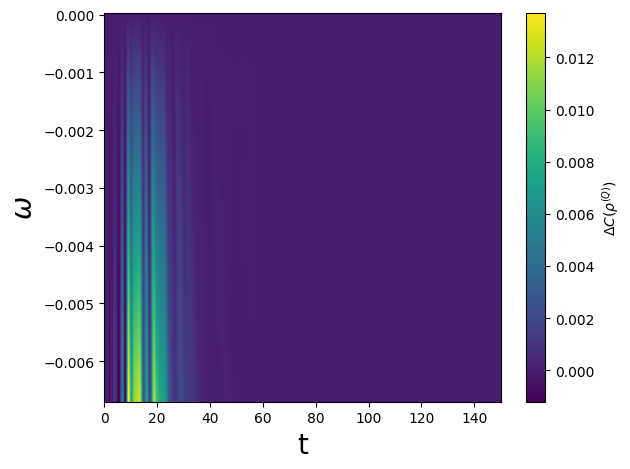

In [217]:
plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt
)

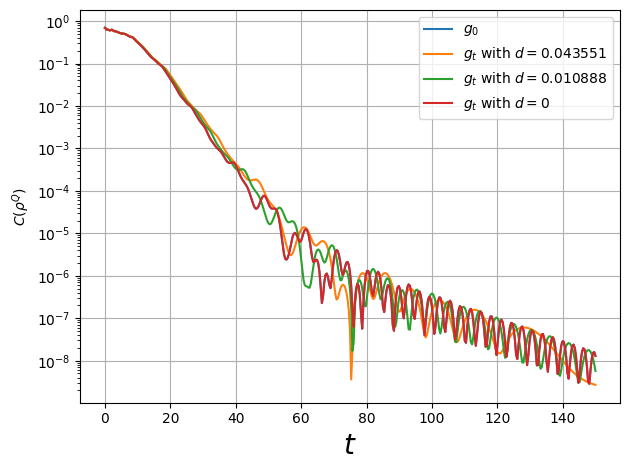

In [218]:
# Aqui aquele d não se aplica, pq sempre é muito menor omega do que os decaimentos
plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices
)


### 2.2.2 - $T$ pequeno
$T=50$

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/2942385320.py:7: 

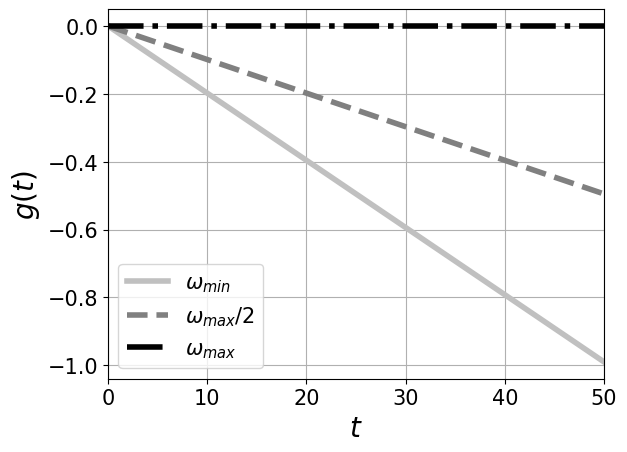

In [219]:
w_list, C_wt, D_wt, const, t = load_coerece('linear5')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']

for i, idx in enumerate(indices):
    g = w_list[idx]*t + 0
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])

plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 10, 20, 30, 40, 50], fontsize=15)
plt.xlim(0, 50)
plt.grid(True)
plt.show()

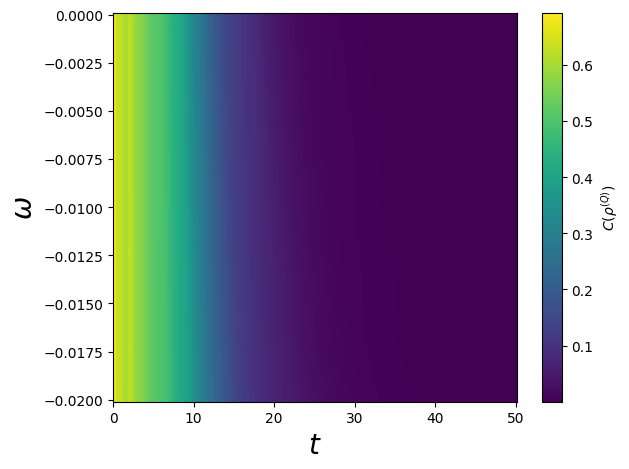

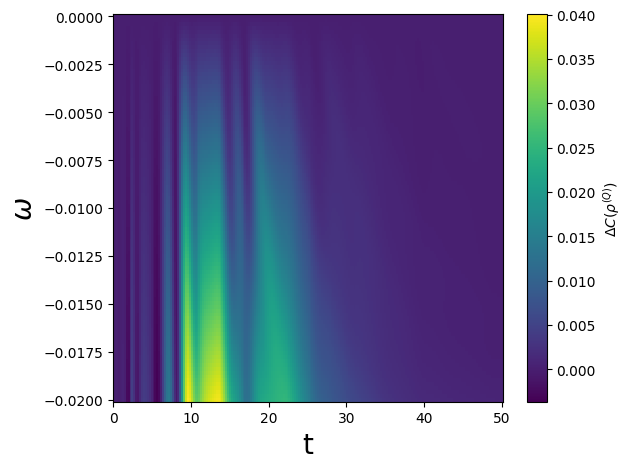

In [220]:
plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt
)

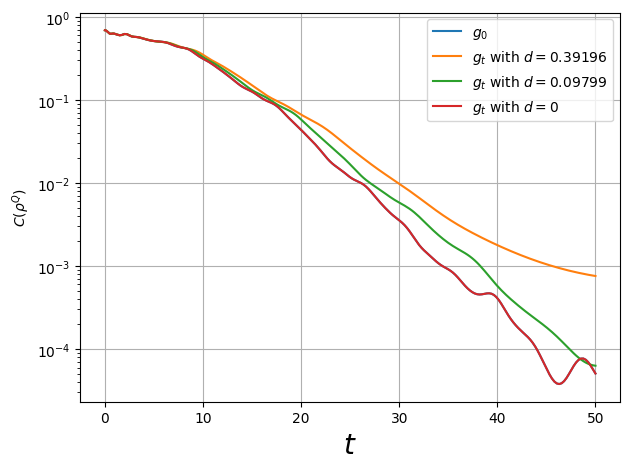

In [221]:
plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices
)


## 2.3 Caso Intermediário
Aqui, vamos verifical tal comportamento fazendo $\phi=0.5$ e $-\frac{1}{2T} < \omega < \frac{1}{2T}$.

### 2.3.1 - $T$ grande
$T=150$

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/1901418601.py:7: 

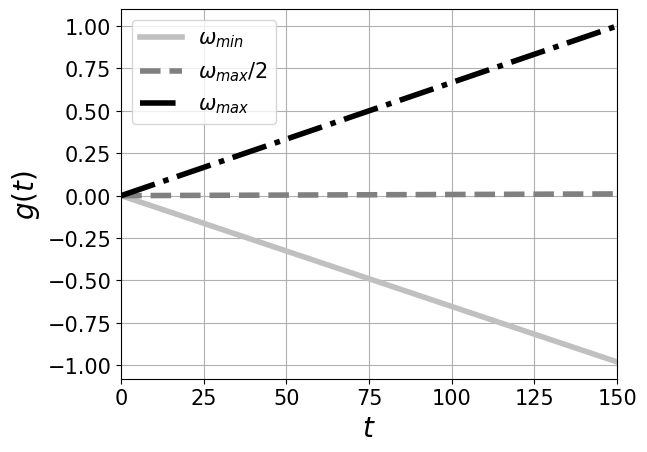

In [222]:
w_list, C_wt, D_wt, const, t = load_coerece('linear3')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']

for i, idx in enumerate(indices):
    g = w_list[idx]*t + 0
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])

plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 25, 50, 75, 100, 125, 150], fontsize=15)
plt.xlim(0, 150)
plt.grid(True)
plt.show()

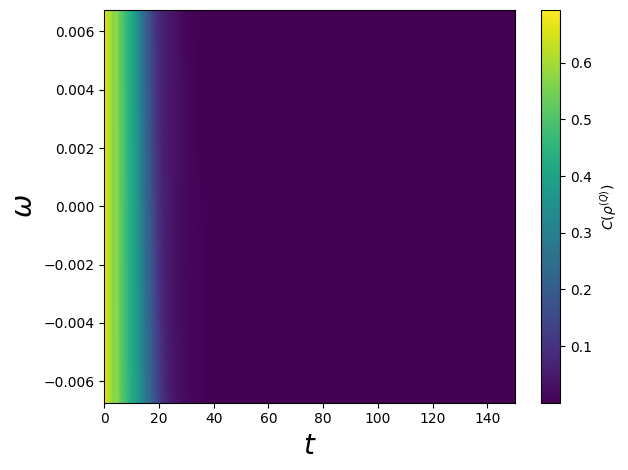

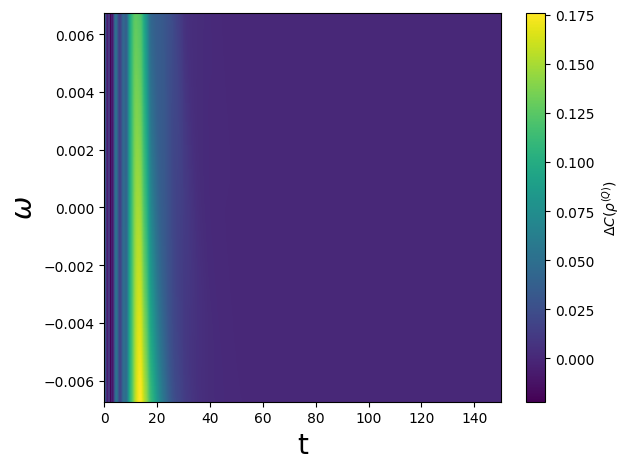

In [223]:
plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt
)

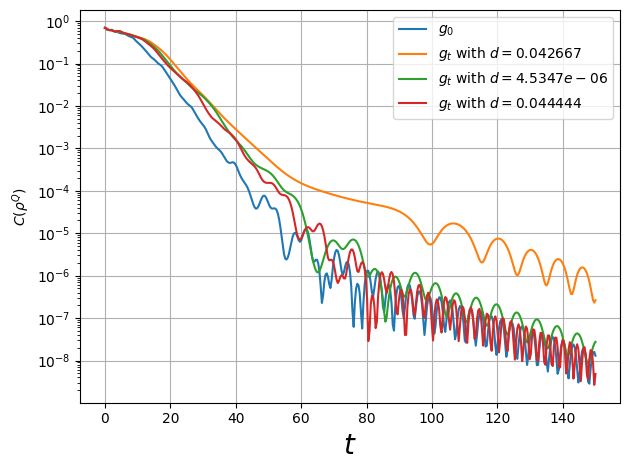

In [224]:
plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices
)


### 2.3.2 - $T$ pequeno
$T=50$

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/2038222929.py:7: 

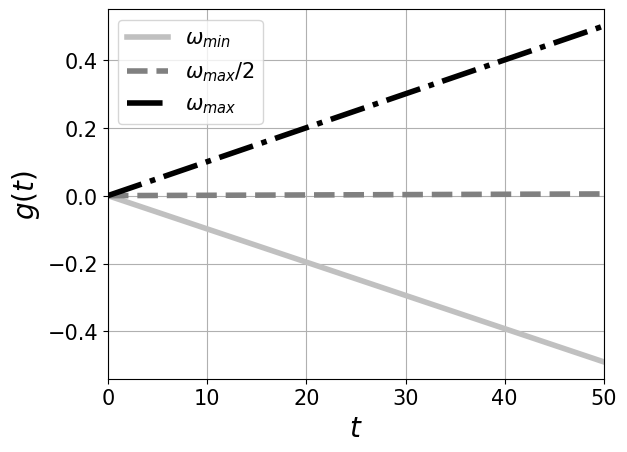

In [225]:
w_list, C_wt, D_wt, const, t = load_coerece('linear6')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']

for i, idx in enumerate(indices):
    g = w_list[idx]*t + 0
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])

plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 10, 20, 30 ,40 ,50], fontsize=15)
plt.xlim(0, 50)
plt.grid(True)
plt.show()

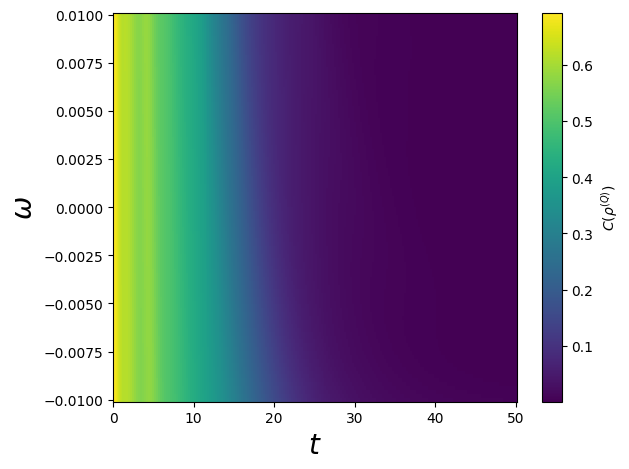

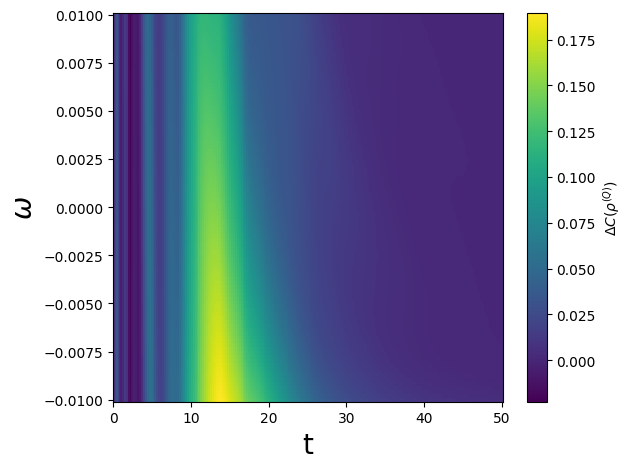

In [226]:
w_list, C_wt, D_wt, const, t = load_coerece('linear6')

plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt
)

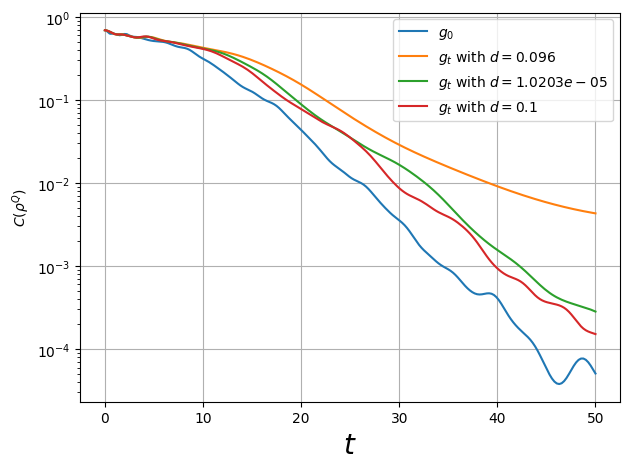

In [227]:
plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices
)


# 3. Gaussiana
Vamos considerar a modulação do tipo gaussiana,

\begin{equation}
    g(t) = g_0 \exp\left[\frac{\sigma(t-T)^2}{\zeta^2}\right],
\end{equation}
mas modificando os tais parâmetros para compreender diferentes cenários físicos.

## 3.1 Pico no meio e variando a espessura do pico
Aqui, vamos verifical tal comportamento fazendo $\sigma=-1$ e $6 < \zeta < 10$.

### 3.1.1 - $T_{max}$ grande
$T=75$

$T_{max}=150$

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/1114092201.py:7: 

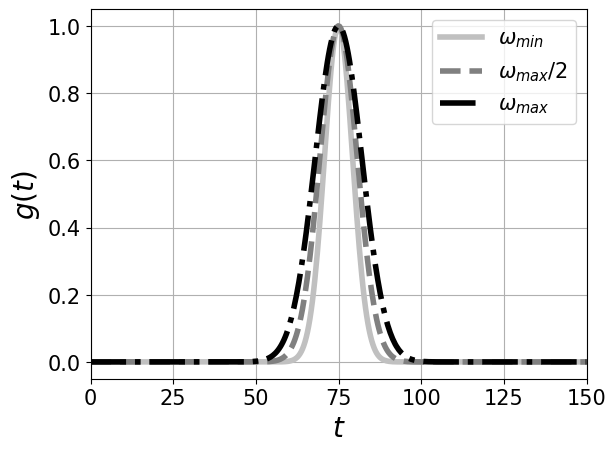

In [228]:
w_list, C_wt, D_wt, const, t = load_coerece('gauss1')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
# NÃO ESTÁ FINALIZADO
for i, idx in enumerate(indices):
    g = np.exp(-(t-75)**2/w_list[idx]**2)
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 25, 50, 75, 100, 125, 150], fontsize=15)
plt.xlim(0, 150)
plt.grid(True)
plt.show()

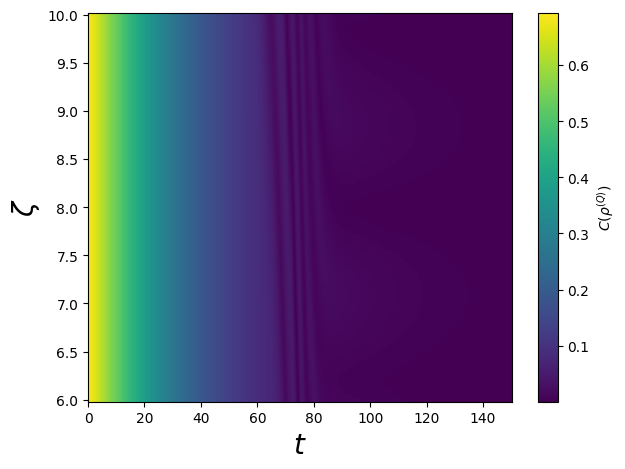

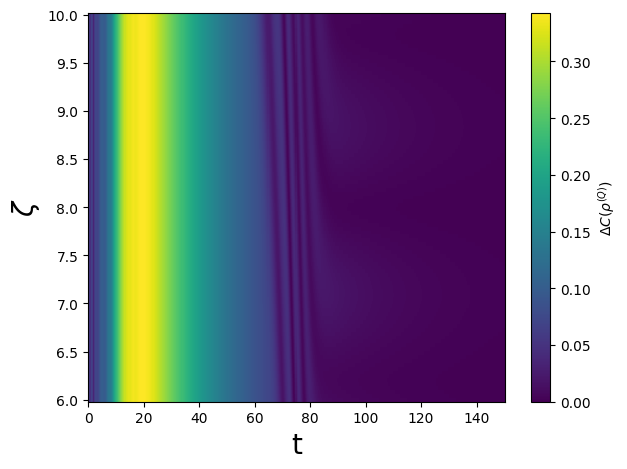

In [229]:
w_list, C_wt, D_wt, const, t = load_coerece('gauss1')

plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt,
    experiment='gauss1'
)

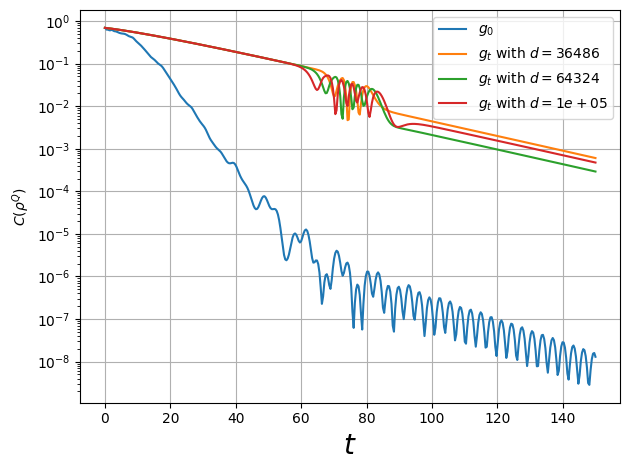

In [230]:
plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
)


### 3.1.2 - $T_{max}$ pequeno
$T=25$

$T_{max}=50$

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/435432406.py:7: S

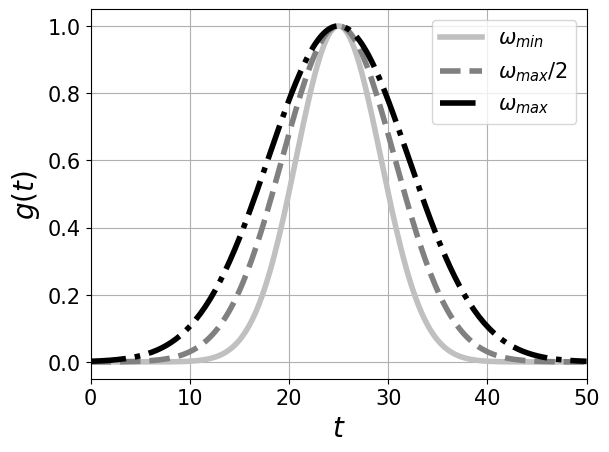

In [231]:
w_list, C_wt, D_wt, const, t = load_coerece('gauss4')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
# NÃO ESTÁ FINALIZADO
for i, idx in enumerate(indices):
    g = np.exp(-(t-25)**2/w_list[idx]**2)
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 10, 20,30,40 ,50], fontsize=15)
plt.xlim(0, 50)
plt.grid(True)
plt.show()

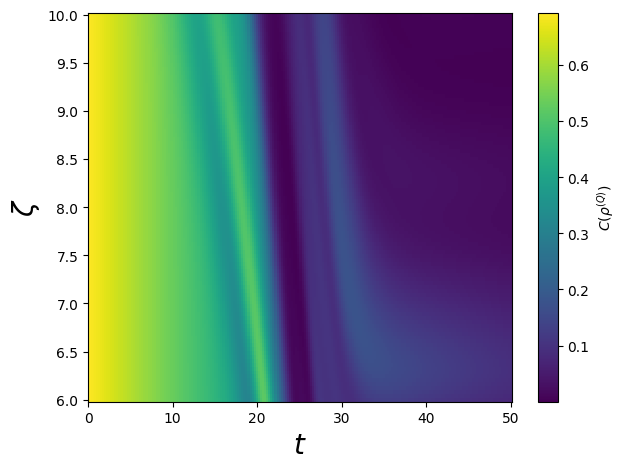

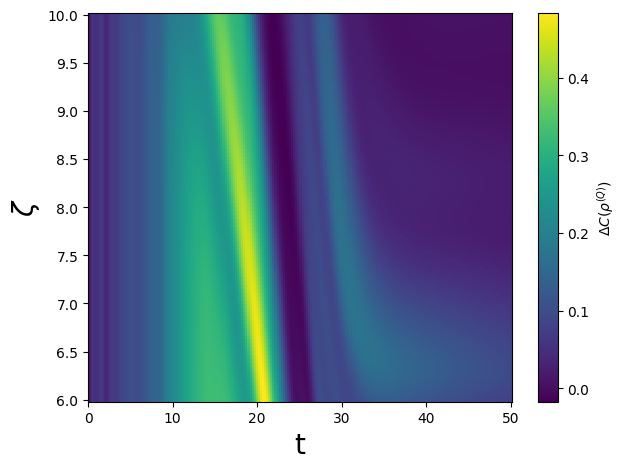

In [232]:
w_list, C_wt, D_wt, const, t = load_coerece('gauss4')

plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt,
    experiment='gauss1'
)

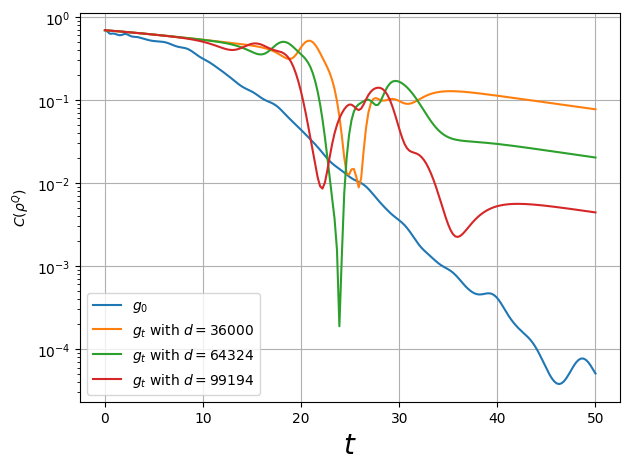

In [233]:
# Aqui não sei como ver essa variação, então só vou plotar primeiro, meio e ultimo. ignore o d no gráfico
indices = [0, len(w_list)//2, -2]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
)


## 3.2 Pico no meio e variando a espessura do pico, para deltas
Aqui, vamos verifical tal comportamento fazendo $\sigma=-1$ e $0 < \zeta < 1$.

### 3.2.1 - $T_{max}$ grande
$T=75$

$T_{max}=150$

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/2179847214.py:7: 

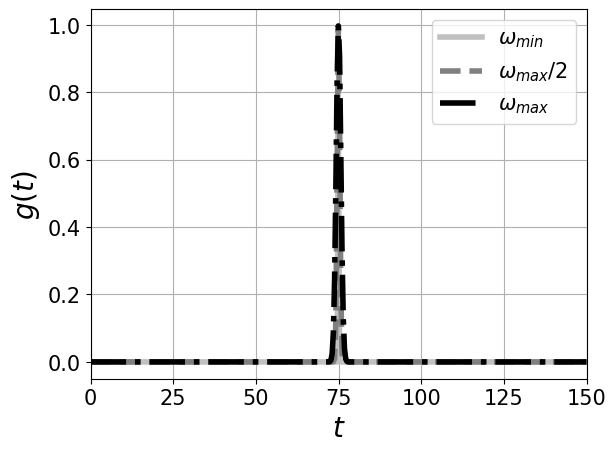

In [234]:
w_list, C_wt, D_wt, const, t = load_coerece('gauss2')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
# NÃO ESTÁ FINALIZADO
for i, idx in enumerate(indices):
    g = np.exp(-(t-75)**2/w_list[idx]**2)
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 25, 50, 75, 100, 125, 150], fontsize=15)
plt.xlim(0, 150)
plt.grid(True)
plt.show()

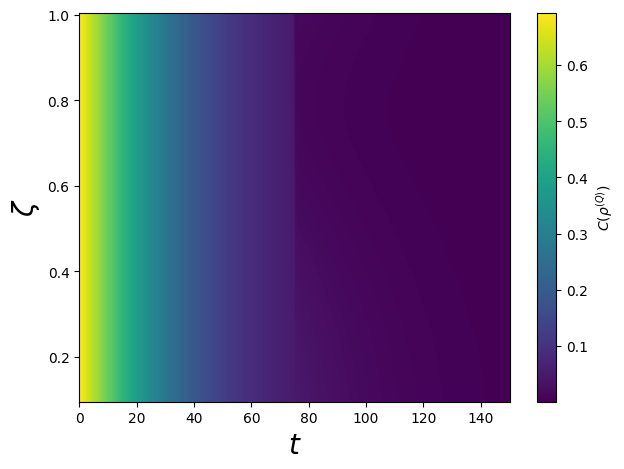

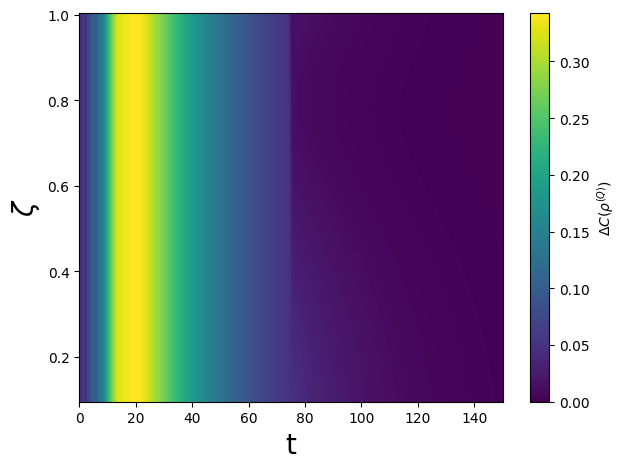

In [235]:
w_list, C_wt, D_wt, const, t = load_coerece('gauss2')

plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt,
    experiment='gauss2'
)

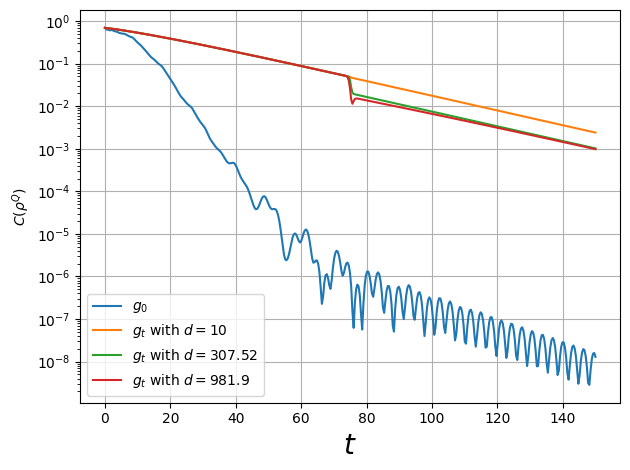

In [236]:
# Aqui não sei como ver essa variação, então só vou plotar primeiro, meio e ultimo. ignore o d no gráfico
indices = [0, len(w_list)//2, -2]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
    
)


### 3.2.2 - $T_{max}$ pequeno

$T=25$

$T_{max}=50$

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/4060521214.py:7: 

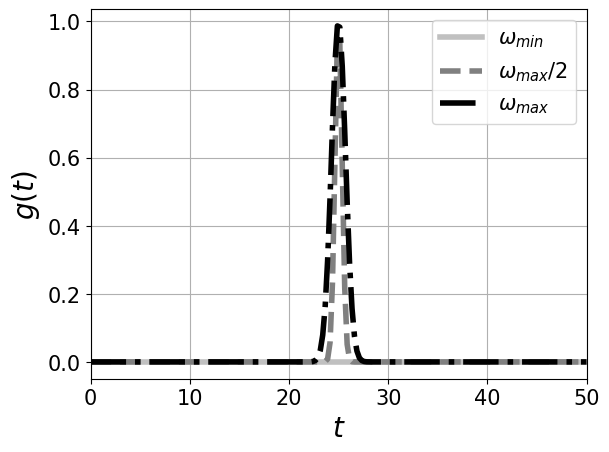

In [237]:
w_list, C_wt, D_wt, const, t = load_coerece('gauss5')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
# NÃO ESTÁ FINALIZADO
for i, idx in enumerate(indices):
    g = np.exp(-(t-25)**2/w_list[idx]**2)
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 10,20,30,40,50], fontsize=15)
plt.xlim(0, 50)
plt.grid(True)
plt.show()

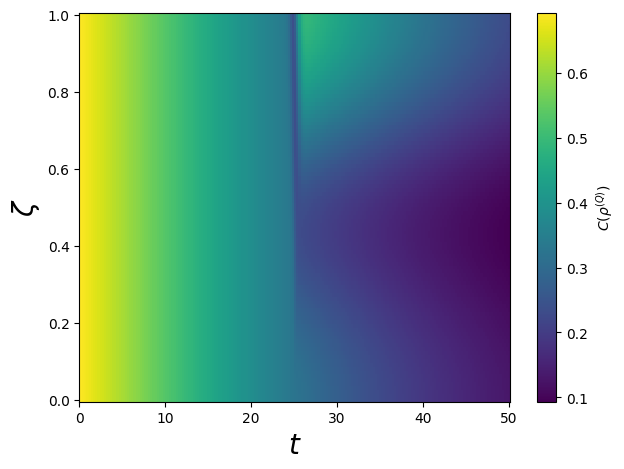

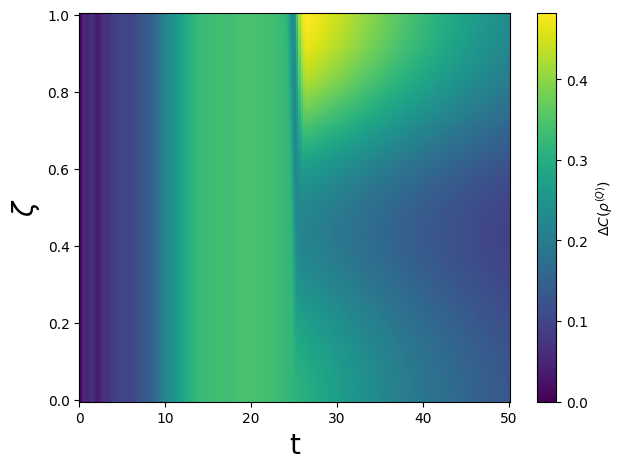

In [238]:
w_list, C_wt, D_wt, const, t = load_coerece('gauss5')

plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt,
    experiment='gauss2'
)

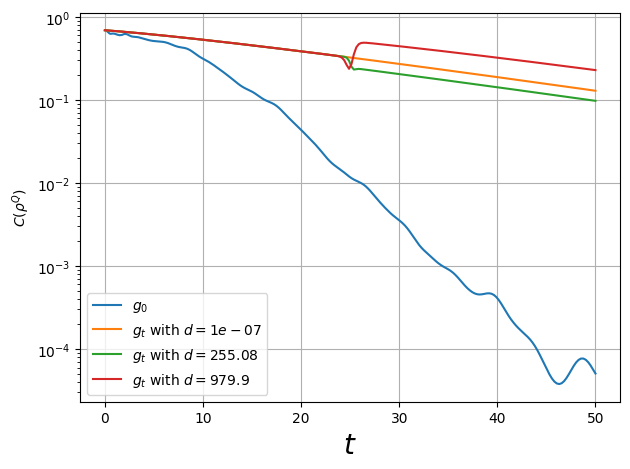

In [239]:
# Aqui não sei como ver essa variação, então só vou plotar primeiro, meio e ultimo. ignore o d no gráfico
indices = [0, len(w_list)//2, -2]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
    
)


## 3.3 - Variando a localização do pico com espessura fixa

$\delta=-1$, $\zeta=8$, $15<T<25$

### 3.3.1 - $T_{max}$ grande

$T_{max}=150$

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/1589377442.py:7: 

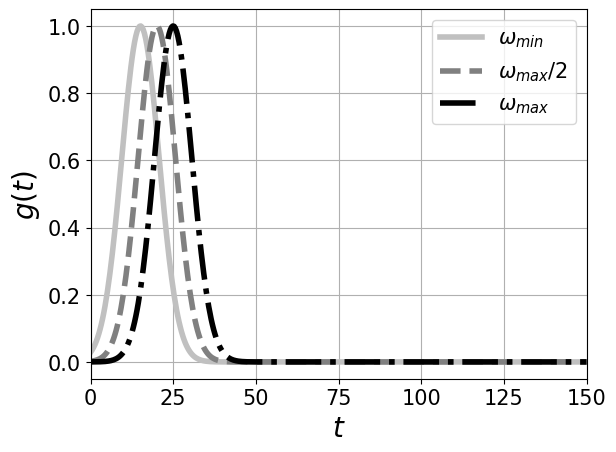

In [240]:
w_list, C_wt, D_wt, const, t = load_coerece('gauss3')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
# NÃO ESTÁ FINALIZADO
for i, idx in enumerate(indices):
    g = np.exp(-(t-w_list[idx])**2/8**2)
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 25, 50, 75, 100, 125, 150], fontsize=15)
plt.xlim(0, 150)
plt.grid(True)
plt.show()

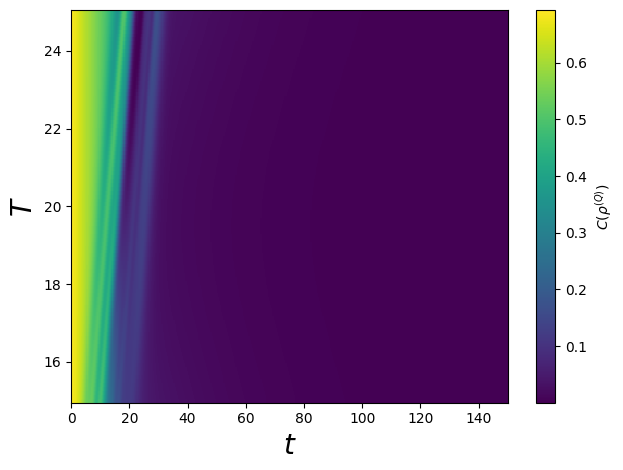

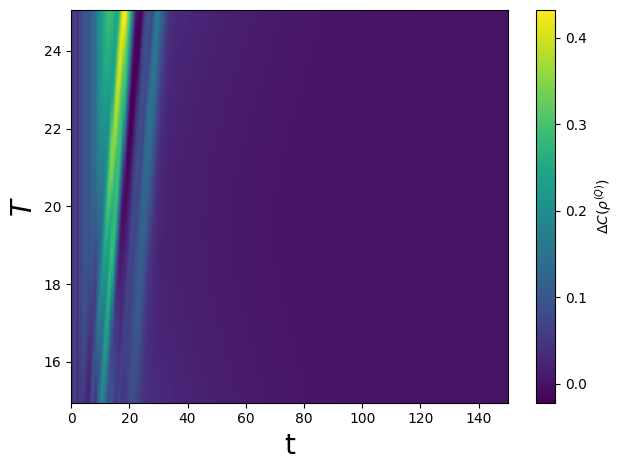

In [241]:
plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt,
    experiment='gauss3'
)

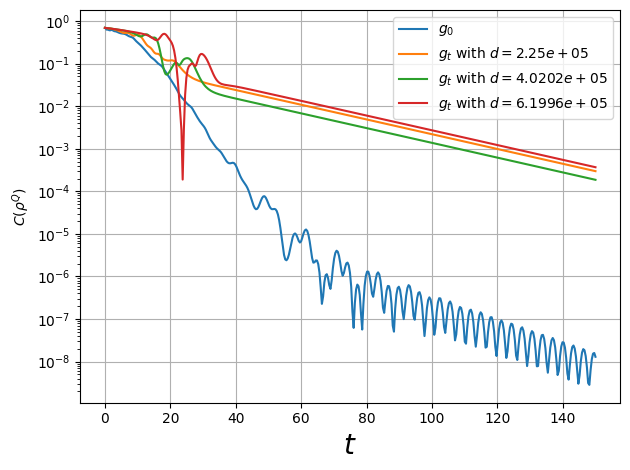

In [242]:
# Aqui não sei como ver essa variação, então só vou plotar primeiro, meio e ultimo. ignore o d no gráfico
indices = [0, len(w_list)//2, -2]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
    
)


### 3.3.2 - $T_{max}$ pequeno
$T_{max}=50$

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/1030773400.py:7: 

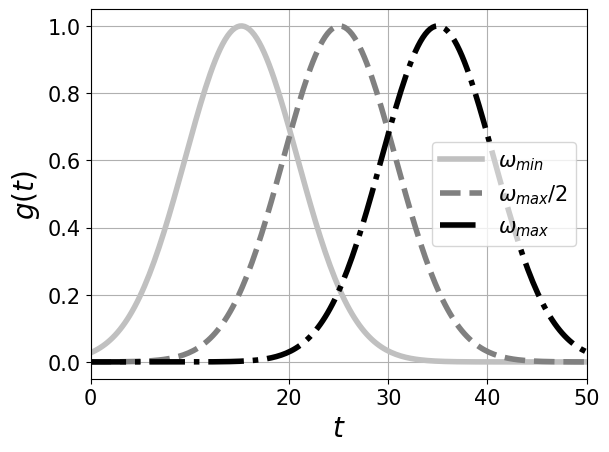

In [243]:
w_list, C_wt, D_wt, const, t = load_coerece('gauss6')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
# NÃO ESTÁ FINALIZADO
for i, idx in enumerate(indices):
    g = np.exp(-(t-w_list[idx])**2/8**2)
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 20,30,40,50], fontsize=15)
plt.xlim(0, 50)
plt.grid(True)
plt.show()

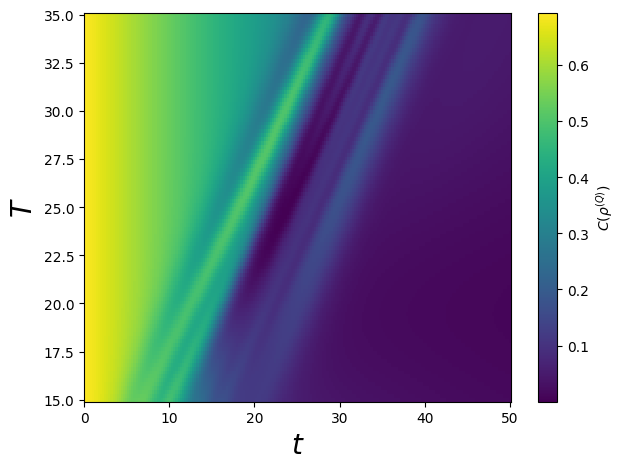

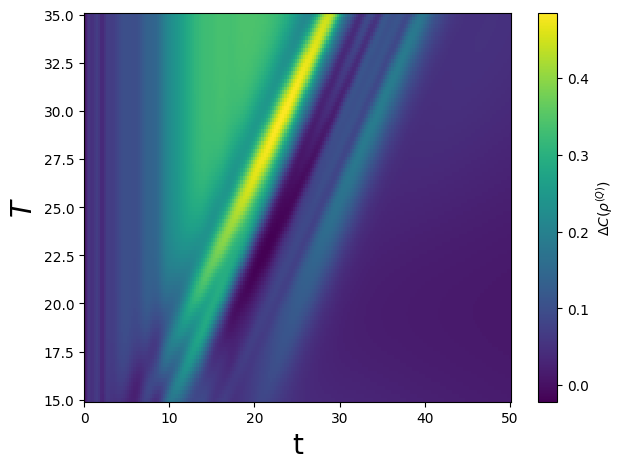

In [244]:
plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt,
    experiment='gauss6'
)

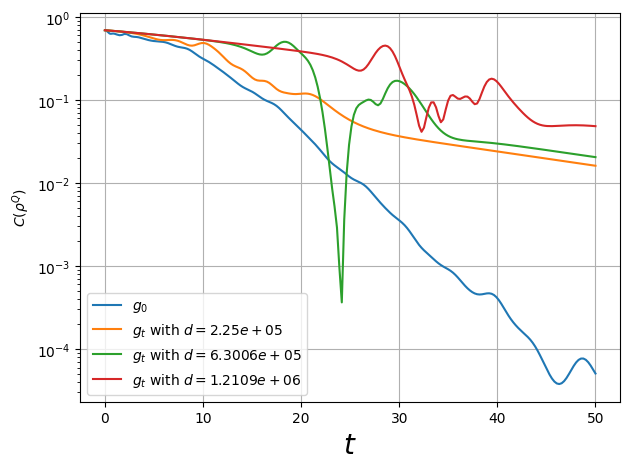

In [245]:
# Aqui não sei como ver essa variação, então só vou plotar primeiro, meio e ultimo. ignore o d no gráfico
indices = [0, len(w_list)//2, -2]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
    
)


# 4. Trigonométricas

Vamos considerar a modulação do tipo,

\begin{equation}
    g(t) = g_0 \cos(\omega t + \phi),
\end{equation}
mas modificando os tais parâmetros para compreender diferentes cenários físicos.

## 4.1 Cosseno
Aqui, vamos verifical tal comportamento fazendo $\phi=0$, $0 < \omega< 2\pi/50$ e $0<t<50$.

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/1714419982.py:7: 

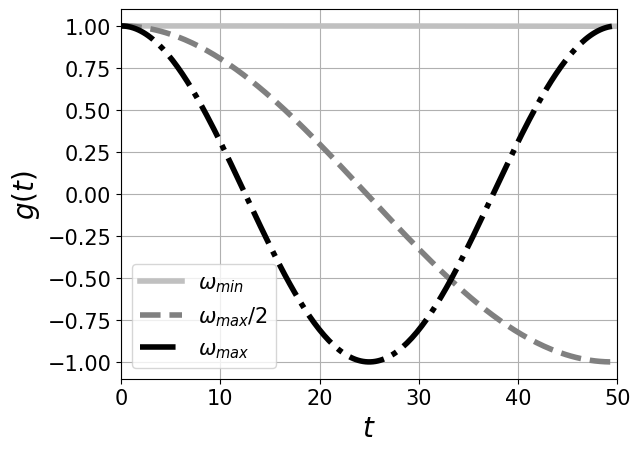

In [246]:
w_list, C_wt, D_wt, const, t = load_coerece('cos1')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
# NÃO ESTÁ FINALIZADO
for i, idx in enumerate(indices):
    g = np.cos(w_list[idx]*t)
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 10, 20,30,40 ,50], fontsize=15)
plt.xlim(0, 50)
plt.grid(True)
plt.show()

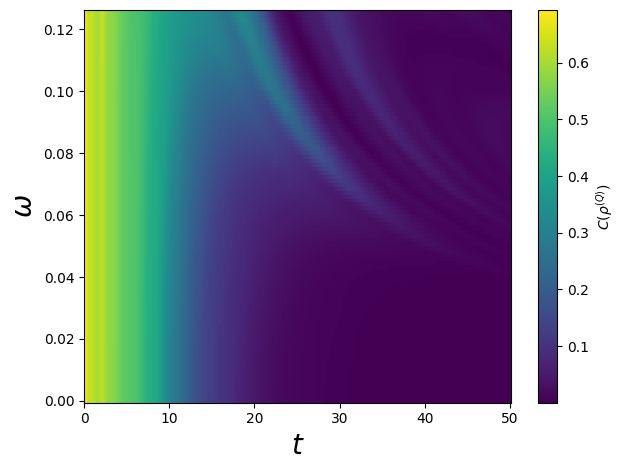

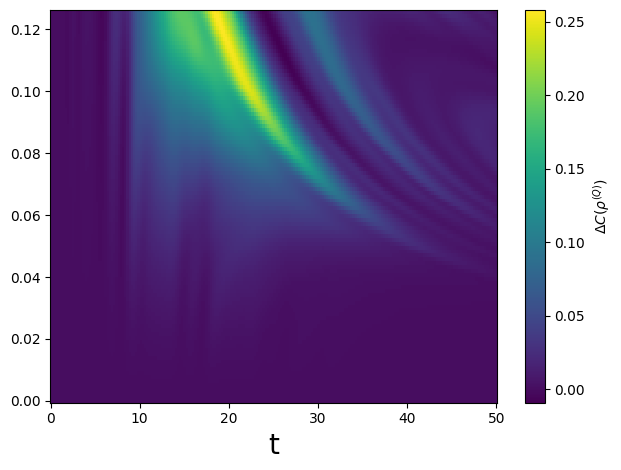

In [247]:
w_list, C_wt, D_wt, const, t = load_coerece('cos1')

plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt,
    experiment='cos1'
)

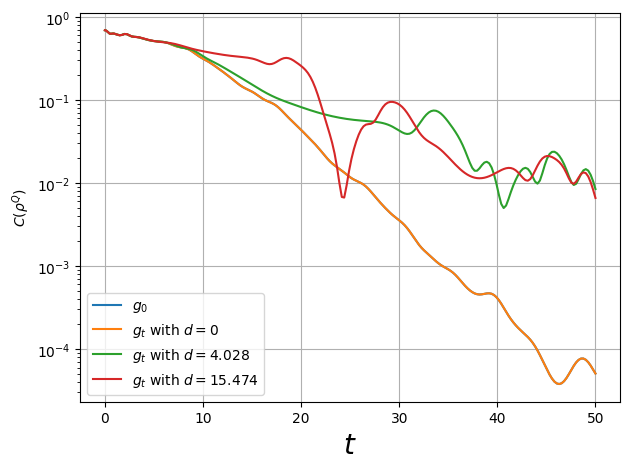

In [248]:
# Aqui não sei como ver essa variação, então só vou plotar primeiro, meio e ultimo. ignore o d no gráfico
indices = [0, len(w_list)//2, -2]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
)


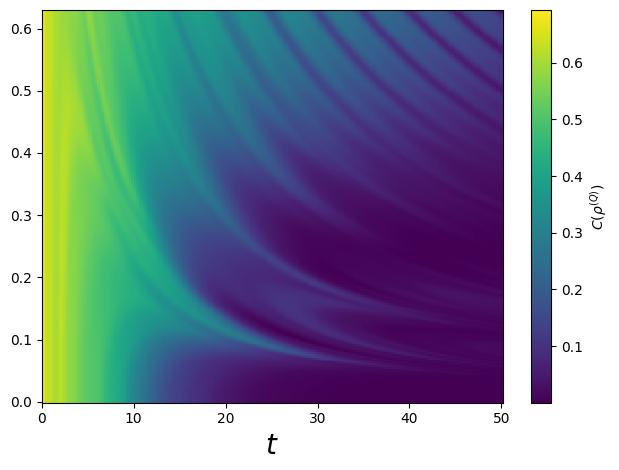

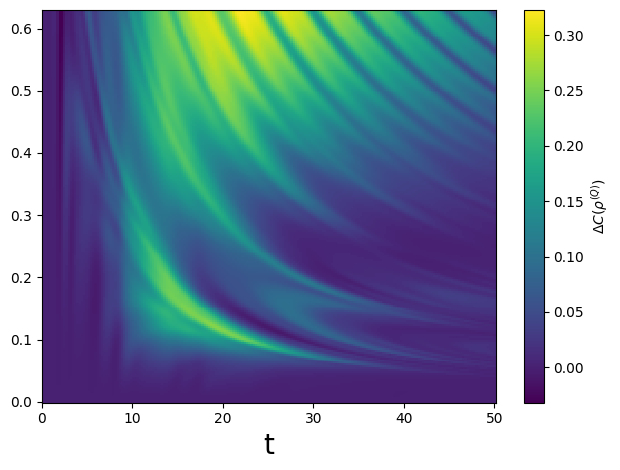

In [249]:
w_list, C_wt, D_wt, const, t = load_coerece('cos5')

plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt,
    experiment='cos5'
)

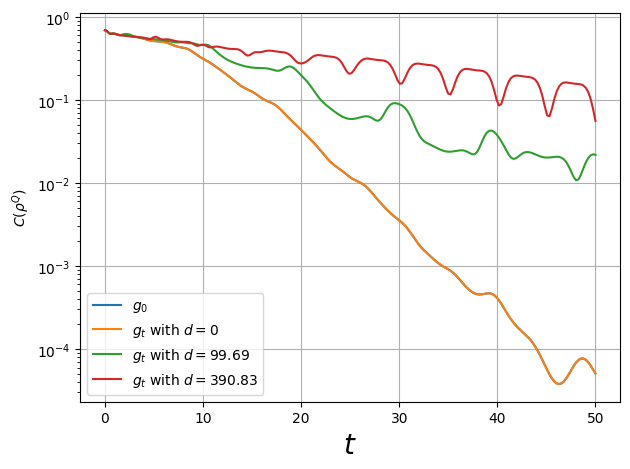

In [250]:
# Aqui não sei como ver essa variação, então só vou plotar primeiro, meio e ultimo. ignore o d no gráfico
indices = [0, len(w_list)//2, -2]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
)


## 4.2 Seno
Aqui, vamos verifical tal comportamento fazendo $\phi=\pi/2$, $0 < \omega< 2\pi/50$ e $0<t<50$.

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/2297847814.py:7: 

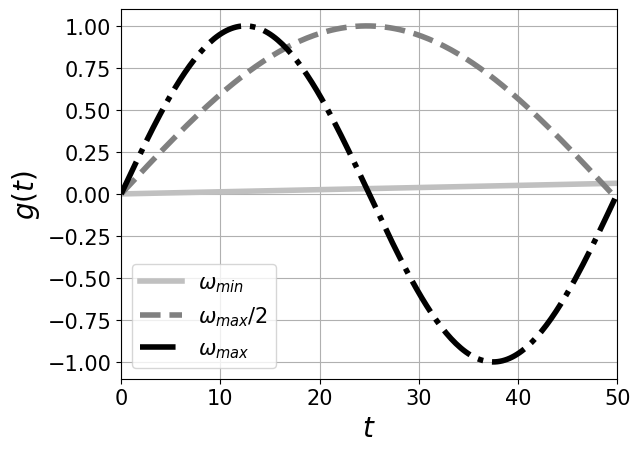

In [251]:
w_list, C_wt, D_wt, const, t = load_coerece('cos2')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
# NÃO ESTÁ FINALIZADO
for i, idx in enumerate(indices):
    g = np.sin(w_list[idx]*t)
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 10,20,30,40,50], fontsize=15)
plt.xlim(0, 50)
plt.grid(True)
plt.show()

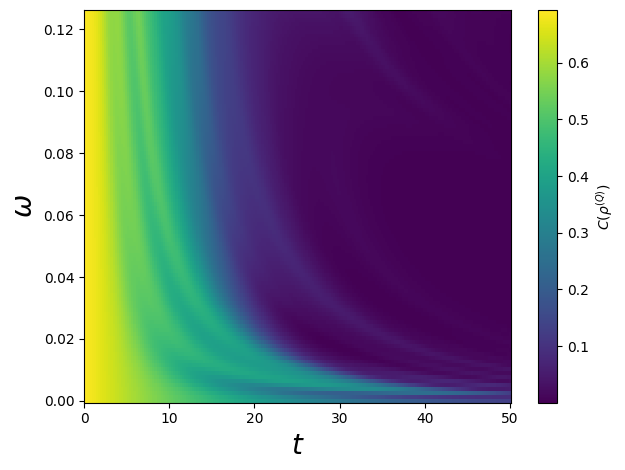

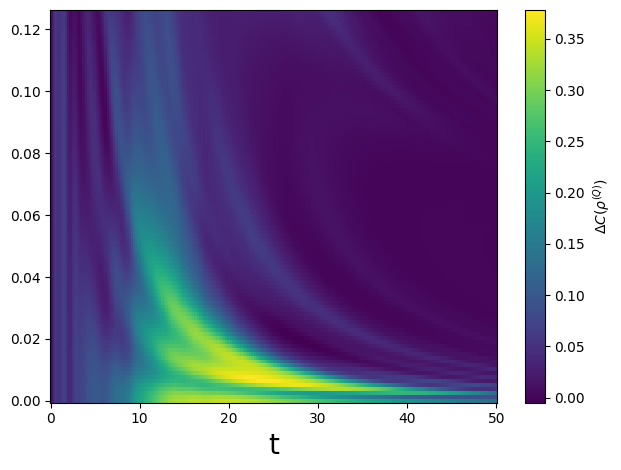

In [252]:
w_list, C_wt, D_wt, const, t = load_coerece('cos2')

plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt,
    experiment='cos2'
)

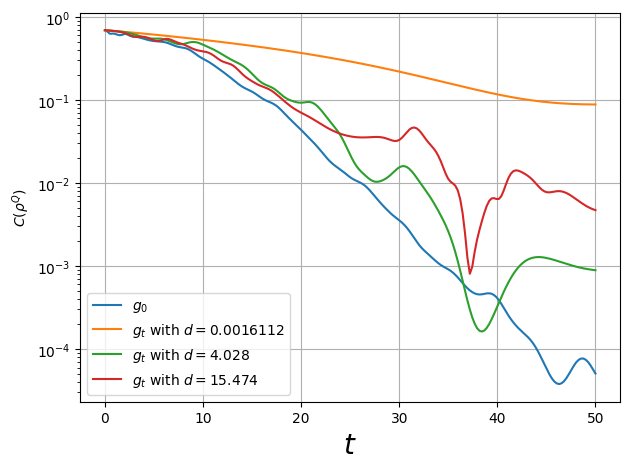

In [253]:
indices = [1, len(w_list)//2, -2]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
    
)


## 4.3 - Sobreposição de cosseno e seno

$\phi=\pi/4$, $0<\omega < 2\pi/50$ e $0<t<50$

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/3840300136.py:7: 

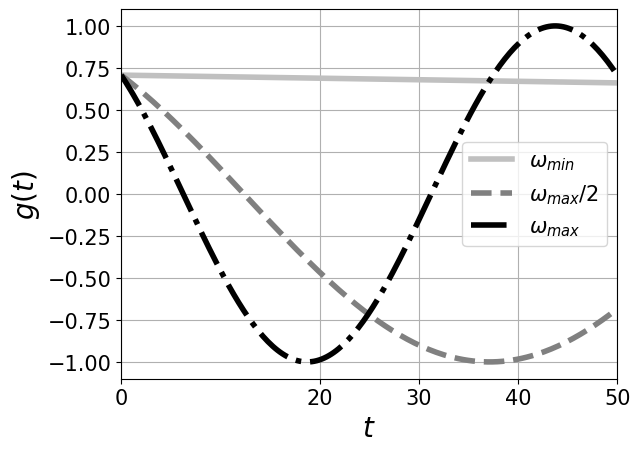

In [254]:
w_list, C_wt, D_wt, const, t = load_coerece('cos3')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
# NÃO ESTÁ FINALIZADO
for i, idx in enumerate(indices):
    g = np.cos(w_list[idx]*t + np.pi/4)
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 20,30,40,50], fontsize=15)
plt.xlim(0, 50)
plt.grid(True)
plt.show()

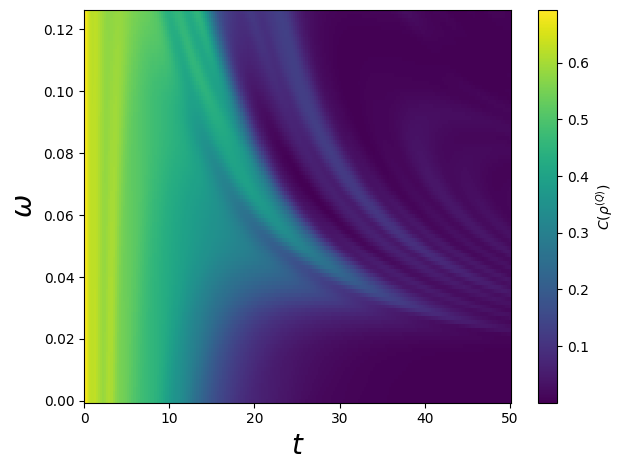

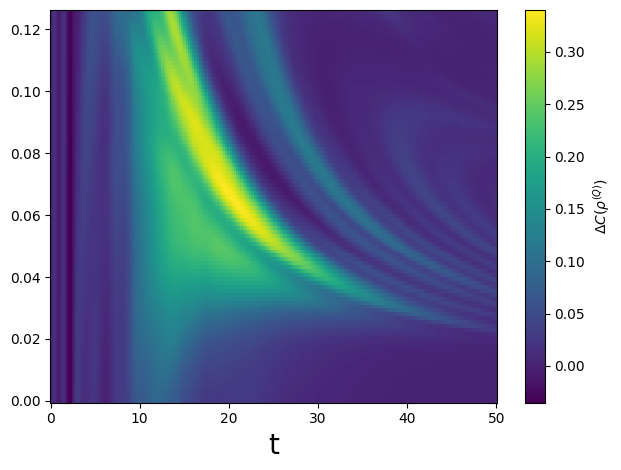

In [255]:
plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt,
    experiment='cos3'
)

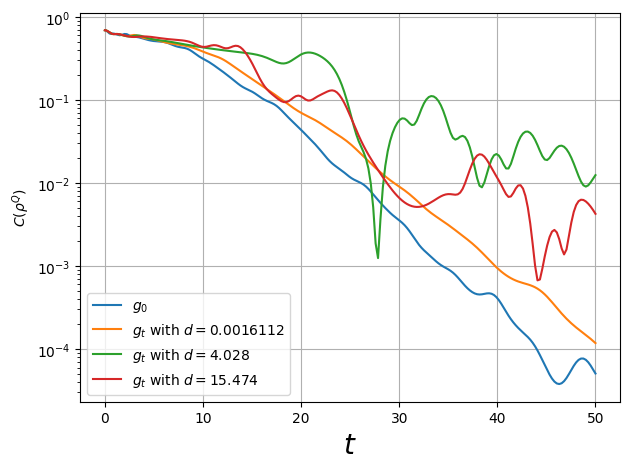

In [256]:
# Aqui não sei como ver essa variação, então só vou plotar primeiro, meio e ultimo. ignore o d no gráfico
indices = [1, len(w_list)//2, -2]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
    
)


## 4.4 Variando phi
Aqui, vamos verificar tal comportamento fazendo $\omega=2\pi/50$, $0 < \phi < \pi/2$ e $0<t<50$.

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/1376445969.py:7: 

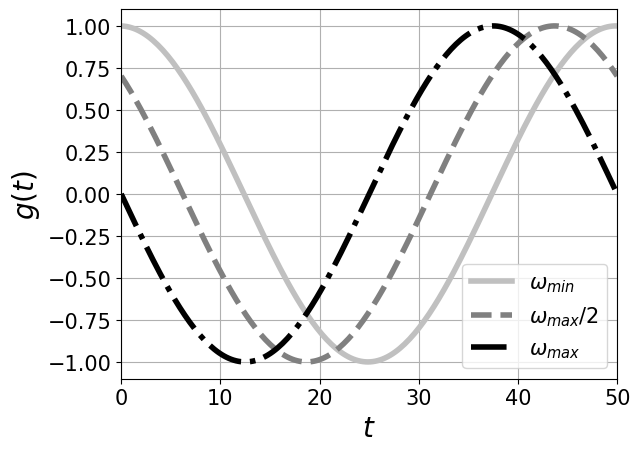

In [257]:
w_list, C_wt, D_wt, const, t = load_coerece('cos4')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
# NÃO ESTÁ FINALIZADO
for i, idx in enumerate(indices):
    g = np.cos(t*np.pi/25 + w_list[idx])
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 10, 20,30,40 ,50], fontsize=15)
plt.xlim(0, 50)
plt.grid(True)
plt.show()

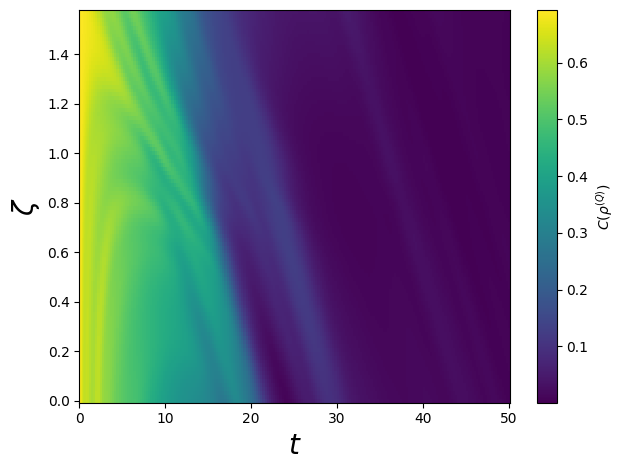

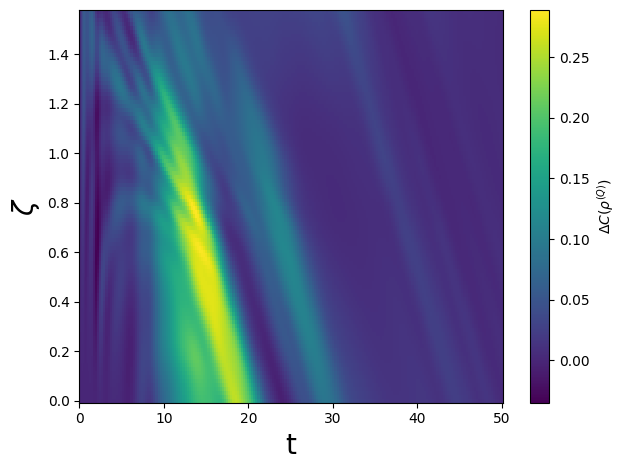

In [258]:
w_list, C_wt, D_wt, const, t = load_coerece('cos4')

plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt,
    experiment='gauss1'
)

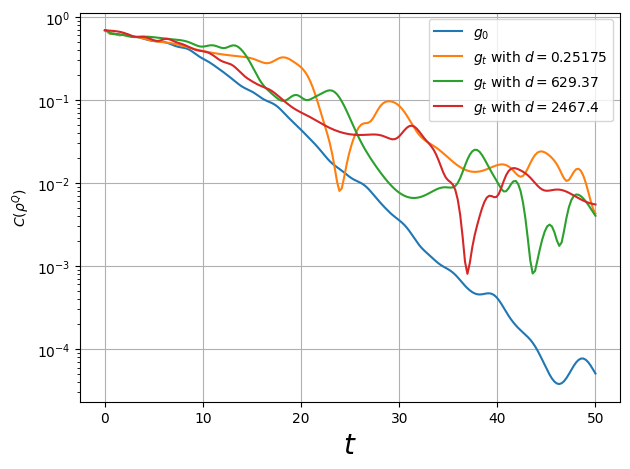

In [259]:
indices = [1, len(w_list)//2, -1]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
)


## 4.1 Cosseno
Aqui, vamos verifical tal comportamento fazendo $\phi=0$, $0 < \omega< 2\pi/50$ e $0<t<50$.

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/1714419982.py:7: 

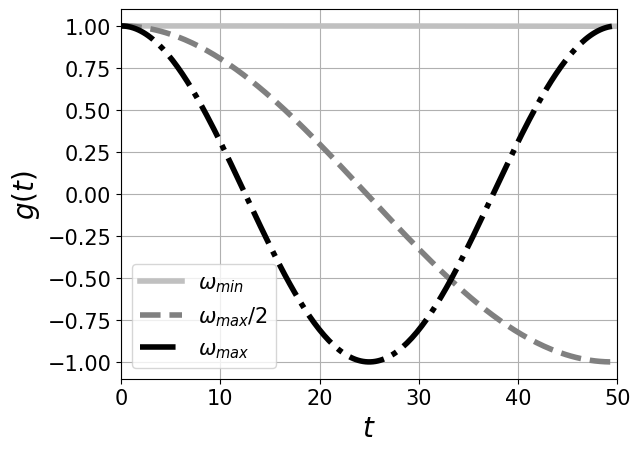

In [260]:
w_list, C_wt, D_wt, const, t = load_coerece('cos1')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
# NÃO ESTÁ FINALIZADO
for i, idx in enumerate(indices):
    g = np.cos(w_list[idx]*t)
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 10, 20,30,40 ,50], fontsize=15)
plt.xlim(0, 50)
plt.grid(True)
plt.show()

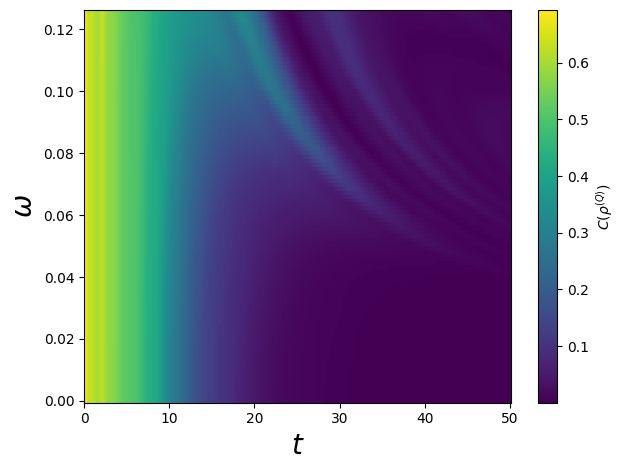

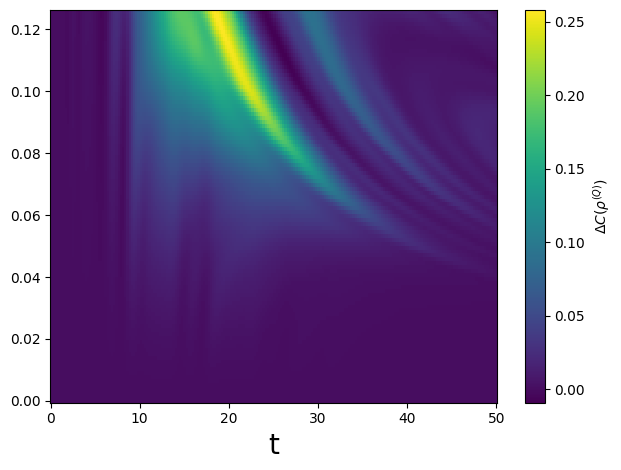

In [261]:
w_list, C_wt, D_wt, const, t = load_coerece('cos1')

plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt,
    experiment='cos1'
)

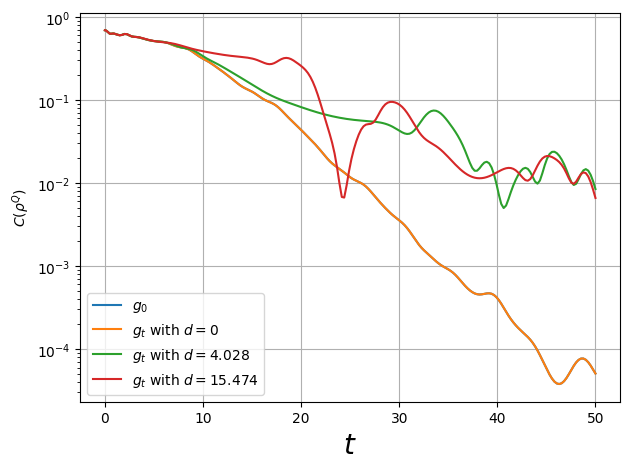

In [262]:
# Aqui não sei como ver essa variação, então só vou plotar primeiro, meio e ultimo. ignore o d no gráfico
indices = [0, len(w_list)//2, -2]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
)


## 4.2 Seno
Aqui, vamos verifical tal comportamento fazendo $\phi=\pi/2$, $0 < \omega< 2\pi/50$ e $0<t<50$.

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/2297847814.py:7: 

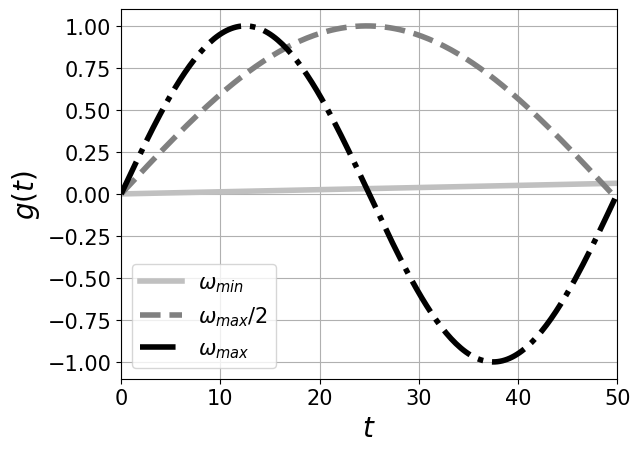

In [263]:
w_list, C_wt, D_wt, const, t = load_coerece('cos2')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
# NÃO ESTÁ FINALIZADO
for i, idx in enumerate(indices):
    g = np.sin(w_list[idx]*t)
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 10,20,30,40,50], fontsize=15)
plt.xlim(0, 50)
plt.grid(True)
plt.show()

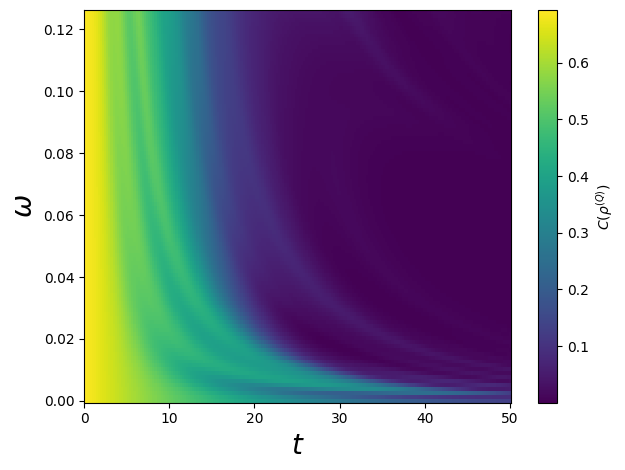

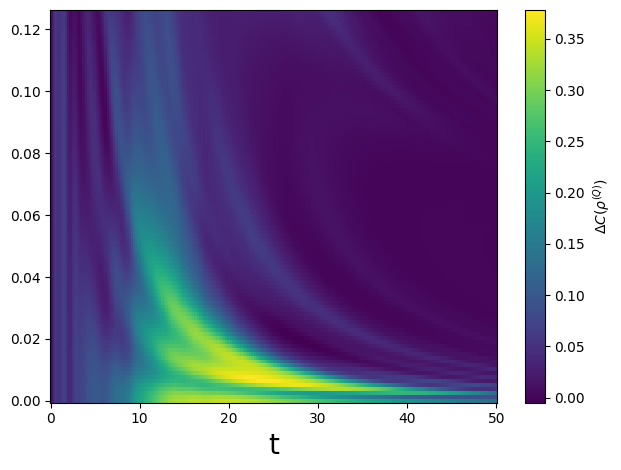

In [264]:
w_list, C_wt, D_wt, const, t = load_coerece('cos2')

plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt,
    experiment='cos2'
)

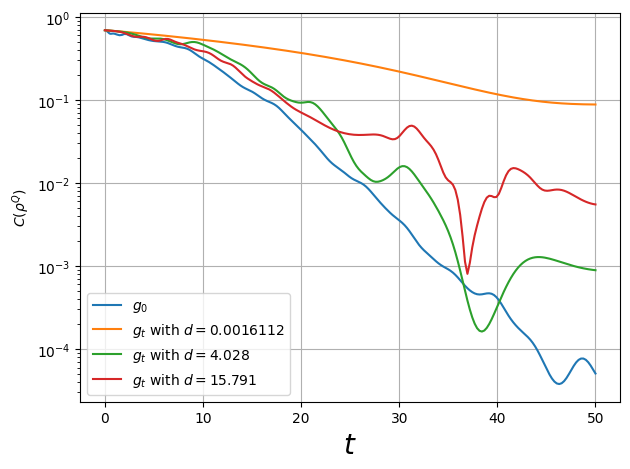

In [265]:
indices = [1, len(w_list)//2, -1]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
    
)


## 4.3 - Sobreposição de cosseno e seno

$\phi=\pi/4$, $0<\omega < 2\pi/50$ e $0<t<50$

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/3840300136.py:7: 

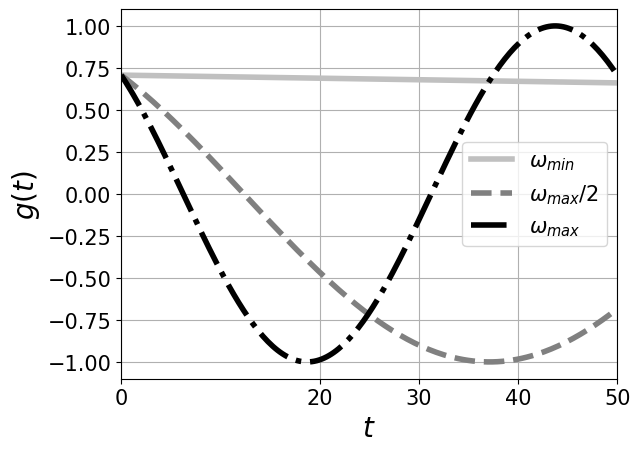

In [266]:
w_list, C_wt, D_wt, const, t = load_coerece('cos3')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
# NÃO ESTÁ FINALIZADO
for i, idx in enumerate(indices):
    g = np.cos(w_list[idx]*t + np.pi/4)
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 20,30,40,50], fontsize=15)
plt.xlim(0, 50)
plt.grid(True)
plt.show()

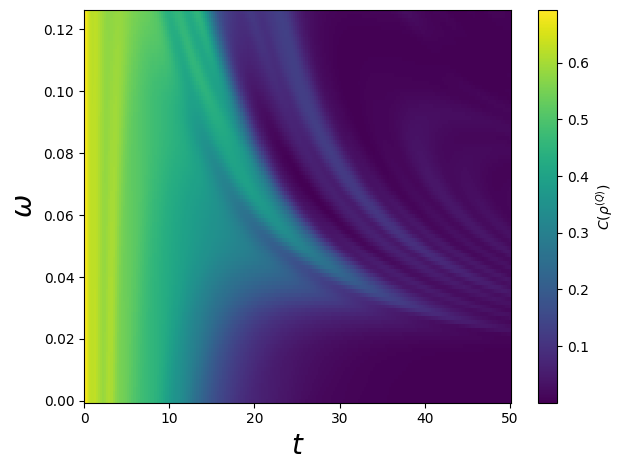

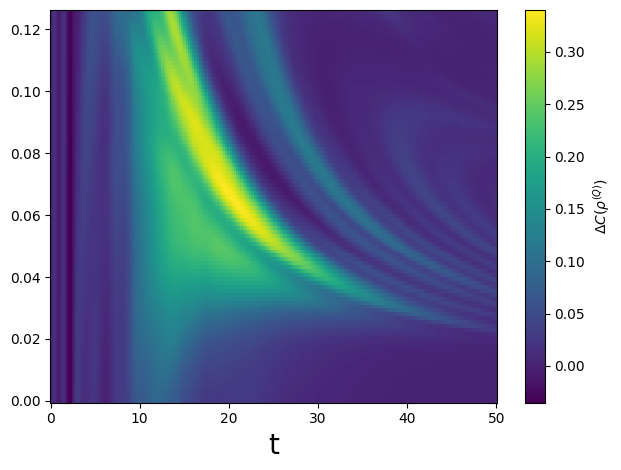

In [267]:
plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt,
    experiment='cos3'
)

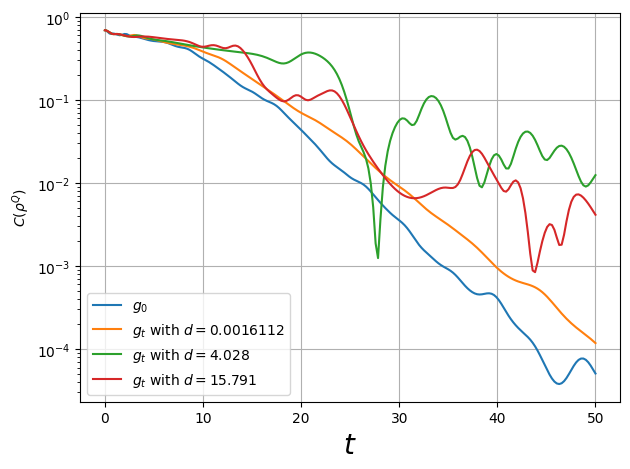

In [268]:
# Aqui não sei como ver essa variação, então só vou plotar primeiro, meio e ultimo. ignore o d no gráfico
indices = [1, len(w_list)//2, -1]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
    
)


## 4.4 Variando phi
Aqui, vamos verificar tal comportamento fazendo $\omega=2\pi/50$, $0 < \phi < \pi/2$ e $0<t<50$.

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_12034/523577016.py:7: S

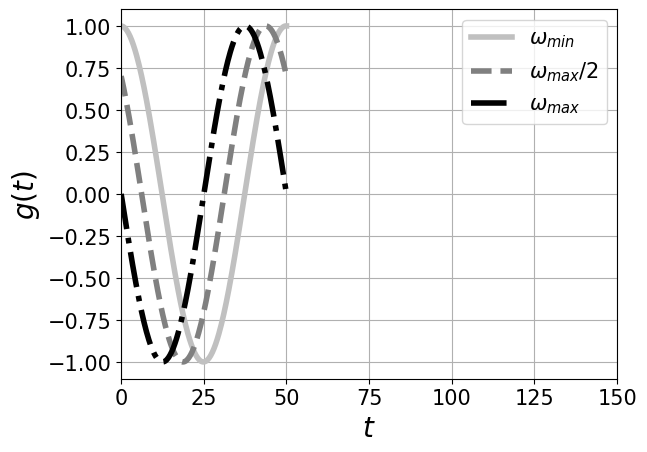

In [269]:
w_list, C_wt, D_wt, const, t = load_coerece('cos4')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
# NÃO ESTÁ FINALIZADO
for i, idx in enumerate(indices):
    g = np.cos(t*np.pi/25 + w_list[idx])
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 25, 50, 75, 100, 125, 150], fontsize=15)
plt.xlim(0, 150)
plt.grid(True)
plt.show()

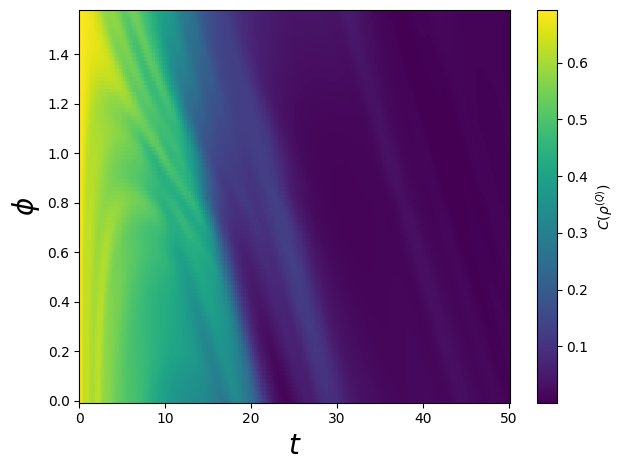

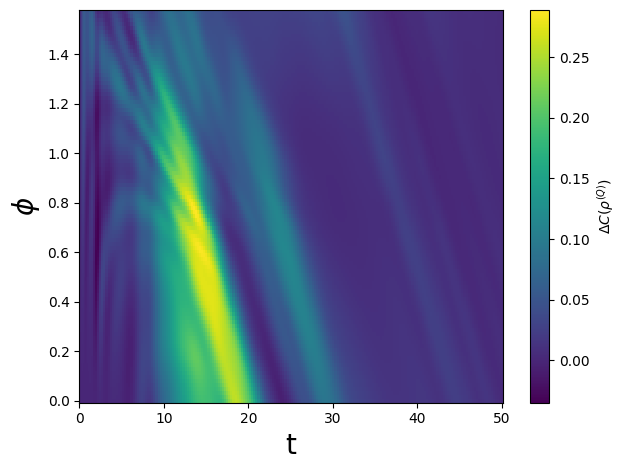

In [270]:
w_list, C_wt, D_wt, const, t = load_coerece('cos4')

plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt,
    experiment='cos4'
)

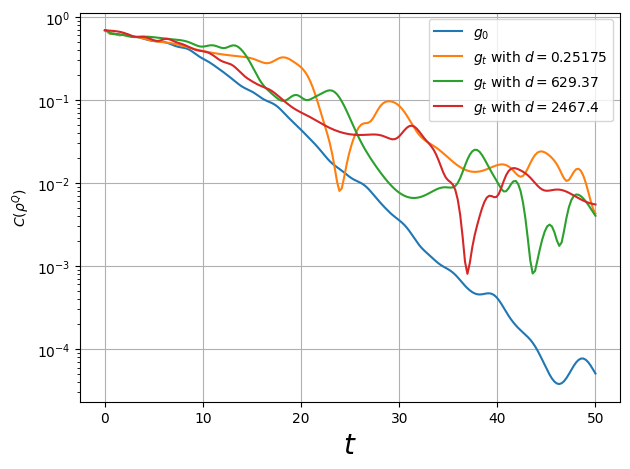

In [271]:
plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
)
